# Exercises XP Ninja - Week 4 Day 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.widgets import Slider
import matplotlib.animation as animation
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Data analysis libraries imported successfully!")
print("Ready for advanced data visualization and analysis")

Data analysis libraries imported successfully!
Ready for advanced data visualization and analysis


## Exercise 1: Temperature Data Visualization



In [ ]:
np.random.seed(42)

cities = ['New York', 'Los Angeles', 'Chicago', 'Miami', 'Denver', 'Seattle']
date_range = pd.date_range('2019-01-01', periods=1825, freq='D')

temperature_data = []

for city in cities:
    city_params = {
        'New York': {'base': 12, 'seasonal': 15, 'std': 3},
        'Los Angeles': {'base': 18, 'seasonal': 8, 'std': 2.5},
        'Chicago': {'base': 9, 'seasonal': 18, 'std': 4},
        'Miami': {'base': 25, 'seasonal': 8, 'std': 2},
        'Denver': {'base': 10, 'seasonal': 16, 'std': 3.5},
        'Seattle': {'base': 11, 'seasonal': 10, 'std': 2.8}
    }
    
    params = city_params[city]
    
    day_of_year = np.array([d.timetuple().tm_yday for d in date_range])
    seasonal_pattern = params['base'] + params['seasonal'] * np.sin(2 * np.pi * day_of_year / 365.25 - np.pi/2)
    daily_noise = np.random.normal(0, params['std'], len(date_range))
    
    extreme_events = np.random.random(len(date_range)) < 0.02
    extreme_adjustments = np.where(extreme_events, 
                                 np.random.choice([-12, -8, 8, 12], len(date_range)),
                                 0)
    
    final_temps = seasonal_pattern + daily_noise + extreme_adjustments
    
    city_df = pd.DataFrame({
        'Date': date_range,
        'City': city,
        'Temperature': final_temps,
        'Year': [d.year for d in date_range],
        'Month': [d.month for d in date_range],
        'DayOfYear': day_of_year
    })
    
    temperature_data.append(city_df)

temp_df = pd.concat(temperature_data, ignore_index=True)

print(f"Temperature dataset created!")
print(f"Shape: {temp_df.shape}")
print(f"Cities: {temp_df['City'].unique()}")
print(f"Date range: {temp_df['Date'].min()} to {temp_df['Date'].max()}")
print(f"\nDataset preview:")
print(temp_df.head())

Temperature dataset created!
Shape: (10950, 6)
Cities: ['New York' 'Los Angeles' 'Chicago' 'Miami' 'Denver' 'Seattle']
Date range: 2019-01-01 00:00:00 to 2023-12-30 00:00:00

Dataset preview:
        Date      City  Temperature  Year  Month  DayOfYear
0 2019-01-01  New York    -1.507638  2019      1          1
1 2019-01-02  New York    -3.405916  2019      1          2
2 2019-01-03  New York    -1.036964  2019      1          3
3 2019-01-04  New York     9.604586  2019      1          4
4 2019-01-05  New York    -3.647009  2019      1          5


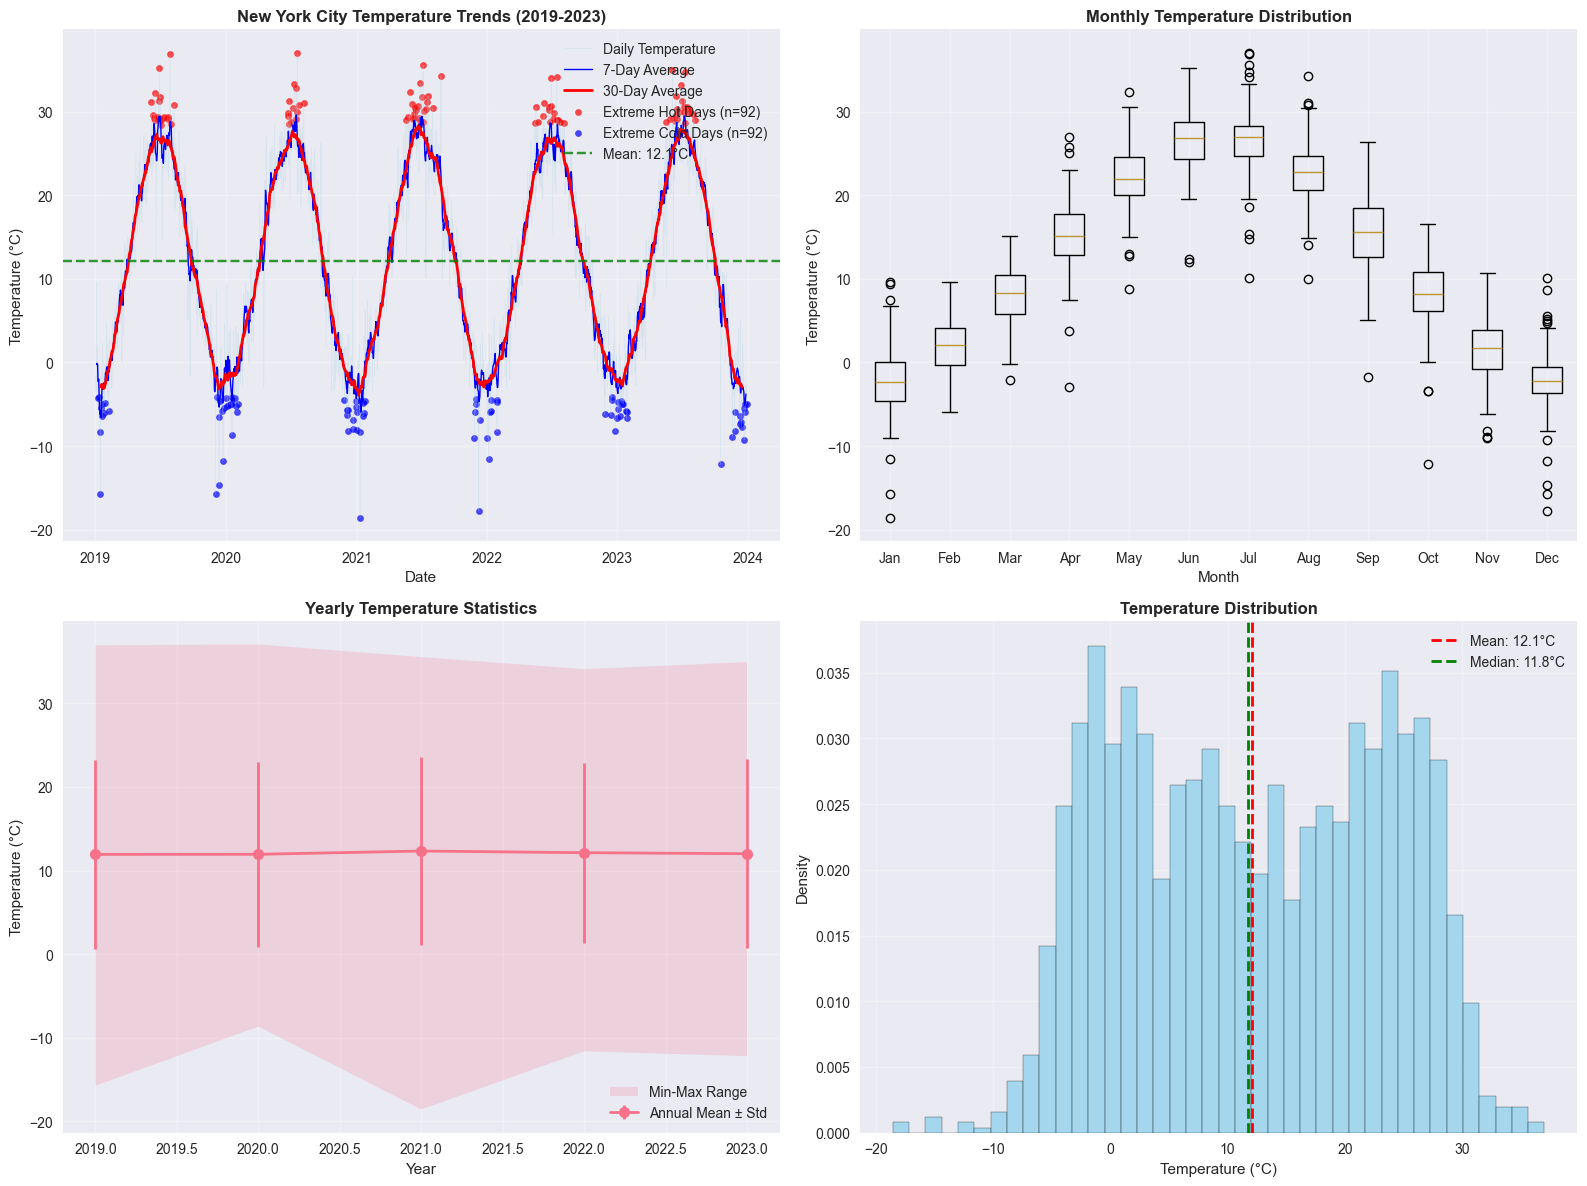

NEW YORK TEMPERATURE ANALYSIS:
Temperature Range: -18.6°C to 37.0°C
Mean Temperature: 12.1°C
Standard Deviation: 11.1°C
Extreme Hot Days (95th percentile): 92 days
Extreme Cold Days (5th percentile): 92 days
Warmest Month (average): 6 (26.6°C)
Coldest Month (average): 12 (-2.3°C)
Most Variable Month: 9 (std: 4.3°C)
Temperature-Time Correlation: 0.0030
Long-term trend: No significant trend detected


In [ ]:
ny_data = temp_df[temp_df['City'] == 'New York'].copy()

#  moving averages 
ny_data['MA_7'] = ny_data['Temperature'].rolling(window=7, center=True).mean()
ny_data['MA_30'] = ny_data['Temperature'].rolling(window=30, center=True).mean()
ny_data['MA_90'] = ny_data['Temperature'].rolling(window=90, center=True).mean()

#  extreme events
temp_q95 = ny_data['Temperature'].quantile(0.95)
temp_q05 = ny_data['Temperature'].quantile(0.05)
extreme_hot = ny_data[ny_data['Temperature'] >= temp_q95]
extreme_cold = ny_data[ny_data['Temperature'] <= temp_q05]

# Monthly statistics
monthly_stats = ny_data.groupby('Month')['Temperature'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).round(2)

# Yearly statistics
yearly_stats = ny_data.groupby('Year')['Temperature'].agg([
    'mean', 'std', 'min', 'max'
]).round(2)

fig = plt.figure(figsize=(16, 12))

# Main temperature plot
ax1 = plt.subplot(2, 2, 1)
ax1.plot(ny_data['Date'], ny_data['Temperature'], 
         alpha=0.3, color='lightblue', linewidth=0.5, label='Daily Temperature')
ax1.plot(ny_data['Date'], ny_data['MA_7'], 
         color='blue', linewidth=1, label='7-Day Average')
ax1.plot(ny_data['Date'], ny_data['MA_30'], 
         color='red', linewidth=2, label='30-Day Average')

# Highlight extreme events
ax1.scatter(extreme_hot['Date'], extreme_hot['Temperature'], 
           color='red', s=20, alpha=0.7, label=f'Extreme Hot Days (n={len(extreme_hot)})')
ax1.scatter(extreme_cold['Date'], extreme_cold['Temperature'], 
           color='blue', s=20, alpha=0.7, label=f'Extreme Cold Days (n={len(extreme_cold)})')

ax1.axhline(y=ny_data['Temperature'].mean(), color='green', linestyle='--', alpha=0.8, 
           label=f'Mean: {ny_data["Temperature"].mean():.1f}°C')

ax1.set_title('New York City Temperature Trends (2019-2023)', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Monthly temperature distribution
ax2 = plt.subplot(2, 2, 2)
monthly_temps = [ny_data[ny_data['Month'] == month]['Temperature'] for month in range(1, 13)]
box_plot = ax2.boxplot(monthly_temps, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax2.set_title('Monthly Temperature Distribution', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Temperature (°C)')
ax2.grid(True, alpha=0.3)

# Yearly temperature trends
ax3 = plt.subplot(2, 2, 3)
ax3.errorbar(yearly_stats.index, yearly_stats['mean'], 
            yerr=yearly_stats['std'], marker='o', capsize=5, 
            linewidth=2, markersize=8, label='Annual Mean ± Std')
ax3.fill_between(yearly_stats.index, yearly_stats['min'], yearly_stats['max'], 
                alpha=0.2, label='Min-Max Range')
ax3.set_title('Yearly Temperature Statistics', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Temperature (°C)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Temperature frequency distribution
ax4 = plt.subplot(2, 2, 4)
ax4.hist(ny_data['Temperature'], bins=40, alpha=0.7, color='skyblue', 
         edgecolor='black', density=True)
ax4.axvline(ny_data['Temperature'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {ny_data["Temperature"].mean():.1f}°C')
ax4.axvline(ny_data['Temperature'].median(), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {ny_data["Temperature"].median():.1f}°C')
ax4.set_title('Temperature Distribution', fontweight='bold')
ax4.set_xlabel('Temperature (°C)')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("NEW YORK TEMPERATURE ANALYSIS:")
print("="*50)
print(f"Temperature Range: {ny_data['Temperature'].min():.1f}°C to {ny_data['Temperature'].max():.1f}°C")
print(f"Mean Temperature: {ny_data['Temperature'].mean():.1f}°C")
print(f"Standard Deviation: {ny_data['Temperature'].std():.1f}°C")
print(f"Extreme Hot Days (95th percentile): {len(extreme_hot)} days")
print(f"Extreme Cold Days (5th percentile): {len(extreme_cold)} days")
print(f"Warmest Month (average): {monthly_stats['mean'].idxmax()} ({monthly_stats['mean'].max():.1f}°C)")
print(f"Coldest Month (average): {monthly_stats['mean'].idxmin()} ({monthly_stats['mean'].min():.1f}°C)")
print(f"Most Variable Month: {monthly_stats['std'].idxmax()} (std: {monthly_stats['std'].max():.1f}°C)")

# Correlation 
ny_data['Days_Since_Start'] = (ny_data['Date'] - ny_data['Date'].min()).dt.days
temp_time_correlation = ny_data['Temperature'].corr(ny_data['Days_Since_Start'])
print(f"Temperature-Time Correlation: {temp_time_correlation:.4f}")
if abs(temp_time_correlation) > 0.1:
    trend = "warming" if temp_time_correlation > 0 else "cooling"
    print(f"Long-term trend: Slight {trend} trend detected")
else:
    print("Long-term trend: No significant trend detected")

## Exercise 2: Hierarchical Data Analysis



In [ ]:
np.random.seed(123)

hierarchical_structure = {
    'USA': {
        'California': ['Los Angeles', 'San Francisco', 'San Diego'],
        'New York': ['New York City', 'Albany', 'Buffalo'],
        'Texas': ['Houston', 'Dallas', 'Austin'],
        'Florida': ['Miami', 'Tampa', 'Orlando']
    },
    'Canada': {
        'Ontario': ['Toronto', 'Ottawa', 'Hamilton'],
        'Quebec': ['Montreal', 'Quebec City', 'Laval'],
        'British Columbia': ['Vancouver', 'Victoria', 'Surrey']
    },
    'Mexico': {
        'Jalisco': ['Guadalajara', 'Zapopan', 'Tlaquepaque'],
        'Nuevo Leon': ['Monterrey', 'Guadalupe', 'San Nicolas']
    }
}

date_range = pd.date_range('2022-01-01', periods=365, freq='D')
hierarchical_data = []

for country, states in hierarchical_structure.items():
    country_base_temps = {'USA': 15, 'Canada': 5, 'Mexico': 22}
    
    for state, cities in states.items():
        state_adjustments = {
            'California': 5, 'New York': -3, 'Texas': 7, 'Florida': 10,
            'Ontario': -2, 'Quebec': -5, 'British Columbia': 3,
            'Jalisco': 3, 'Nuevo Leon': 0
        }
        
        for city in cities:
            base_temp = country_base_temps[country] + state_adjustments.get(state, 0)
            
            for date in date_range:
                day_of_year = date.timetuple().tm_yday
                seasonal_temp = base_temp + 12 * np.sin(2 * np.pi * day_of_year / 365.25 - np.pi/2)
                daily_variation = np.random.normal(0, 2.5)
                final_temp = seasonal_temp + daily_variation
                
                hierarchical_data.append({
                    'Country': country,
                    'State': state,
                    'City': city,
                    'Date': date,
                    'Temperature': final_temp,
                    'Month': date.month,
                    'Season': 'Winter' if date.month in [12,1,2] else 
                             'Spring' if date.month in [3,4,5] else
                             'Summer' if date.month in [6,7,8] else 'Fall'
                })

hier_df = pd.DataFrame(hierarchical_data)
hier_indexed = hier_df.set_index(['Country', 'State', 'City', 'Date'])

print("Hierarchical dataset created!")
print(f"Shape: {hier_df.shape}")
print(f"Countries: {hier_df['Country'].unique()}")
print(f"Total States: {hier_df['State'].nunique()}")
print(f"Total Cities: {hier_df['City'].nunique()}")
print(f"\nHierarchical index structure:")
print(hier_indexed.index.names)
print(f"\nSample data:")
print(hier_df.head())

Hierarchical dataset created!
Shape: (9855, 7)
Countries: ['USA' 'Canada' 'Mexico']
Total States: 9
Total Cities: 27

Hierarchical index structure:
['Country', 'State', 'City', 'Date']

Sample data:
  Country       State         City       Date  Temperature  Month  Season
0     USA  California  Los Angeles 2022-01-01     5.287699      1  Winter
1     USA  California  Los Angeles 2022-01-02    10.500465      1  Winter
2     USA  California  Los Angeles 2022-01-03     8.723423      1  Winter
3     USA  California  Los Angeles 2022-01-04     4.262661      1  Winter
4     USA  California  Los Angeles 2022-01-05     6.597861      1  Winter


In [ ]:

target_country = 'USA'
target_state = 'California'
target_city = 'Los Angeles'
start_date = '2022-06-01'
end_date = '2022-08-31'

print("HIERARCHICAL DATA FILTERING:")
print("="*60)

print(f"Original dataset size: {len(hier_df):,} records")

# Filter by country
country_filter = hier_df['Country'] == target_country
country_data = hier_df[country_filter]
print(f"After country filter ({target_country}): {len(country_data):,} records")

# Filter by state
state_filter = country_data['State'] == target_state
state_data = country_data[state_filter]
print(f"After state filter ({target_state}): {len(state_data):,} records")

# Filter by city
city_filter = state_data['City'] == target_city
city_data = state_data[city_filter]
print(f"After city filter ({target_city}): {len(city_data):,} records")

# Filter by date range
date_filter = (city_data['Date'] >= start_date) & (city_data['Date'] <= end_date)
filtered_data = city_data[date_filter].copy()
print(f"After date filter ({start_date} to {end_date}): {len(filtered_data):,} records")

stats = {
    'mean': filtered_data['Temperature'].mean(),
    'median': filtered_data['Temperature'].median(),
    'std': filtered_data['Temperature'].std(),
    'min': filtered_data['Temperature'].min(),
    'max': filtered_data['Temperature'].max(),
    'q25': filtered_data['Temperature'].quantile(0.25),
    'q75': filtered_data['Temperature'].quantile(0.75)
}

# Weekly and monthly aggregations
filtered_data['Week'] = filtered_data['Date'].dt.isocalendar().week
weekly_stats = filtered_data.groupby('Week')['Temperature'].agg(['mean', 'std', 'min', 'max'])
monthly_stats = filtered_data.groupby('Month')['Temperature'].agg(['mean', 'std', 'count'])

print(f"\nSTATISTICAL ANALYSIS:")
print(f"Mean Temperature: {stats['mean']:.2f}°C")
print(f"Median Temperature: {stats['median']:.2f}°C")
print(f"Standard Deviation: {stats['std']:.2f}°C")
print(f"Temperature Range: {stats['min']:.1f}°C to {stats['max']:.1f}°C")
print(f"Interquartile Range: {stats['q25']:.1f}°C to {stats['q75']:.1f}°C")

HIERARCHICAL DATA FILTERING:
Original dataset size: 9,855 records
After country filter (USA): 4,380 records
After state filter (California): 1,095 records
After city filter (Los Angeles): 365 records
After date filter (2022-06-01 to 2022-08-31): 92 records

STATISTICAL ANALYSIS:
Mean Temperature: 30.15°C
Median Temperature: 30.71°C
Standard Deviation: 2.76°C
Temperature Range: 23.6°C to 36.8°C
Interquartile Range: 28.2°C to 32.0°C
After date filter (2022-06-01 to 2022-08-31): 92 records

STATISTICAL ANALYSIS:
Mean Temperature: 30.15°C
Median Temperature: 30.71°C
Standard Deviation: 2.76°C
Temperature Range: 23.6°C to 36.8°C
Interquartile Range: 28.2°C to 32.0°C


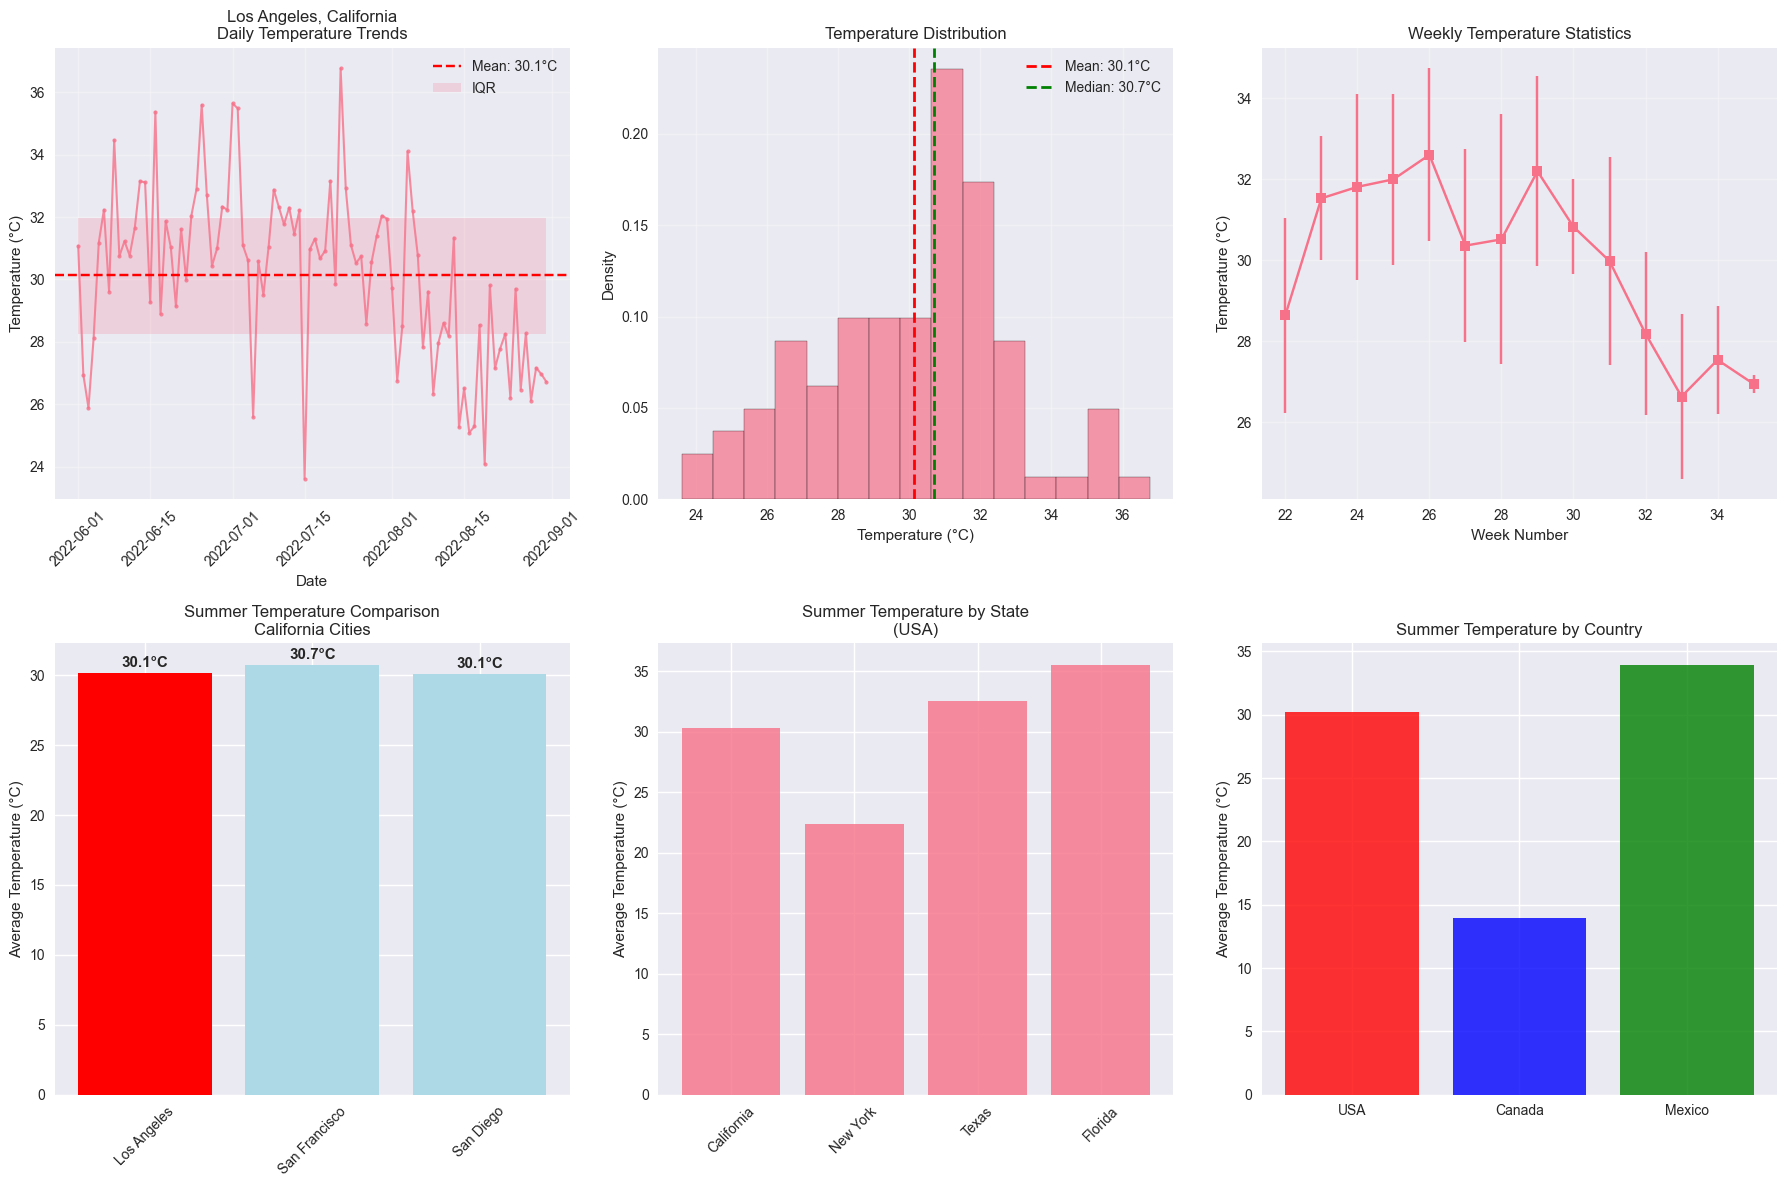


HIERARCHICAL ANALYSIS INSIGHTS:
Country-level temperature statistics:
          mean    std
Country              
Canada    3.71   9.39
Mexico   23.48   8.97
USA      19.80  10.05

USA State-level temperature statistics:
             mean   std
State                  
California  19.92  8.88
Florida     25.16  8.77
New York    12.07  8.73
Texas       22.07  8.87

Seasonal analysis for Los Angeles:
         mean   std  count
Season                    
Summer  30.15  2.76     92


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Daily temperature trend
ax1 = axes[0, 0]
ax1.plot(filtered_data['Date'], filtered_data['Temperature'], 
         marker='o', linewidth=1.5, markersize=3, alpha=0.8)
ax1.axhline(y=stats['mean'], color='red', linestyle='--', 
           label=f"Mean: {stats['mean']:.1f}°C")
ax1.fill_between(filtered_data['Date'], stats['q25'], stats['q75'], 
                alpha=0.2, label='IQR')
ax1.set_title(f'{target_city}, {target_state}\nDaily Temperature Trends')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Temperature distribution
ax2 = axes[0, 1]
ax2.hist(filtered_data['Temperature'], bins=15, alpha=0.7, 
         edgecolor='black', density=True)
ax2.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, 
           label=f"Mean: {stats['mean']:.1f}°C")
ax2.axvline(stats['median'], color='green', linestyle='--', linewidth=2, 
           label=f"Median: {stats['median']:.1f}°C")
ax2.set_title('Temperature Distribution')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Weekly temperature trends
ax3 = axes[0, 2]
ax3.errorbar(weekly_stats.index, weekly_stats['mean'], 
            yerr=weekly_stats['std'], marker='s', capsize=5)
ax3.set_title('Weekly Temperature Statistics')
ax3.set_xlabel('Week Number')
ax3.set_ylabel('Temperature (°C)')
ax3.grid(True, alpha=0.3)

#  Compare with other California cities
ax4 = axes[1, 0]
california_cities = ['Los Angeles', 'San Francisco', 'San Diego']
city_summer_means = []

for city in california_cities:
    city_summer = hier_df[(hier_df['Country'] == 'USA') & 
                         (hier_df['State'] == 'California') & 
                         (hier_df['City'] == city) & 
                         (hier_df['Date'] >= start_date) & 
                         (hier_df['Date'] <= end_date)]['Temperature'].mean()
    city_summer_means.append(city_summer)

bars = ax4.bar(california_cities, city_summer_means, 
               color=['red' if city == target_city else 'lightblue' 
                     for city in california_cities])
ax4.set_title('Summer Temperature Comparison\nCalifornia Cities')
ax4.set_ylabel('Average Temperature (°C)')
ax4.tick_params(axis='x', rotation=45)

for bar, temp in zip(bars, city_summer_means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
            f'{temp:.1f}°C', ha='center', va='bottom', fontweight='bold')

ax5 = axes[1, 1]
usa_states = ['California', 'New York', 'Texas', 'Florida']
state_summer_means = []

for state in usa_states:
    state_summer = hier_df[(hier_df['Country'] == 'USA') & 
                          (hier_df['State'] == state) & 
                          (hier_df['Date'] >= start_date) & 
                          (hier_df['Date'] <= end_date)]['Temperature'].mean()
    state_summer_means.append(state_summer)

ax5.bar(usa_states, state_summer_means, alpha=0.8)
ax5.set_title('Summer Temperature by State\n(USA)')
ax5.set_ylabel('Average Temperature (°C)')
ax5.tick_params(axis='x', rotation=45)

#  Country comparison
ax6 = axes[1, 2]
countries = ['USA', 'Canada', 'Mexico']
country_summer_means = []

for country in countries:
    country_summer = hier_df[(hier_df['Country'] == country) & 
                            (hier_df['Date'] >= start_date) & 
                            (hier_df['Date'] <= end_date)]['Temperature'].mean()
    country_summer_means.append(country_summer)

ax6.bar(countries, country_summer_means, alpha=0.8, color=['red', 'blue', 'green'])
ax6.set_title('Summer Temperature by Country')
ax6.set_ylabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

print("\nHIERARCHICAL ANALYSIS INSIGHTS:")
print("="*50)

country_analysis = hier_df.groupby(['Country'])['Temperature'].agg(['mean', 'std']).round(2)
print("Country-level temperature statistics:")
print(country_analysis)

usa_state_analysis = hier_df[hier_df['Country'] == 'USA'].groupby(['State'])['Temperature'].agg(['mean', 'std']).round(2)
print(f"\nUSA State-level temperature statistics:")
print(usa_state_analysis)

target_seasonal = filtered_data.groupby('Season')['Temperature'].agg(['mean', 'std', 'count']).round(2)
print(f"\nSeasonal analysis for {target_city}:")
print(target_seasonal)

## Exercise 3: Dynamic Subplot Configuration with User Interaction



Generating 2 subplots...


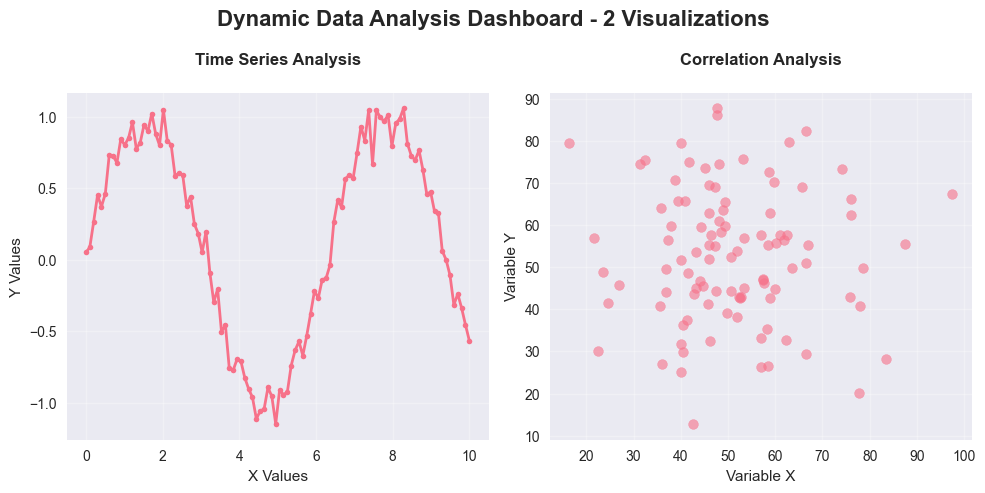

Generating 4 subplots...


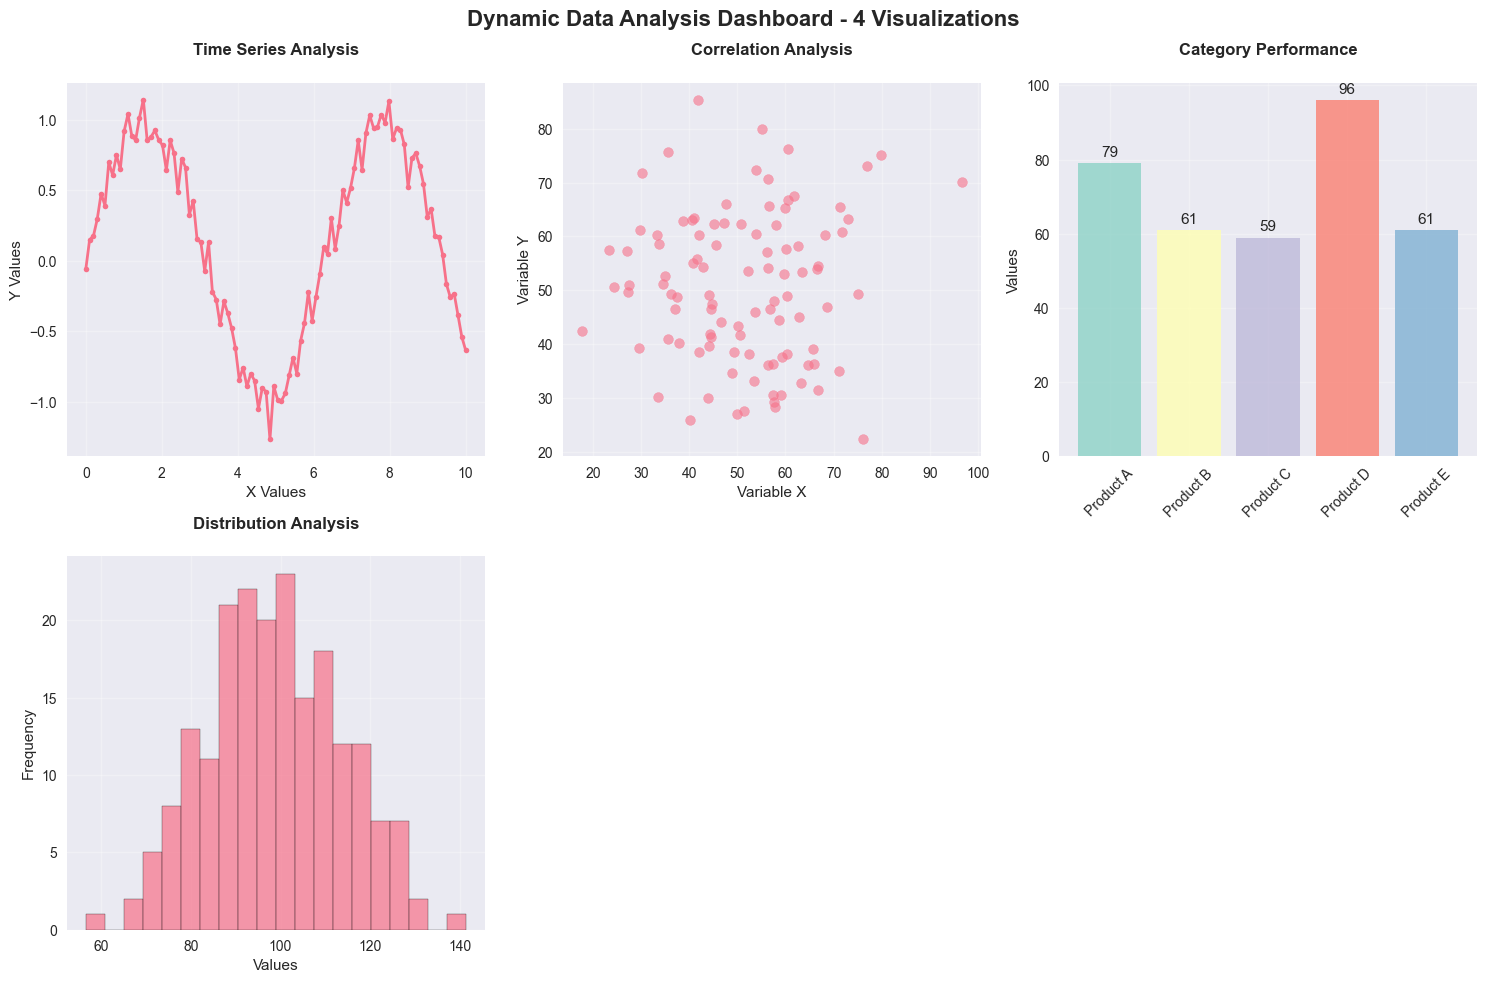

Generating 6 subplots...


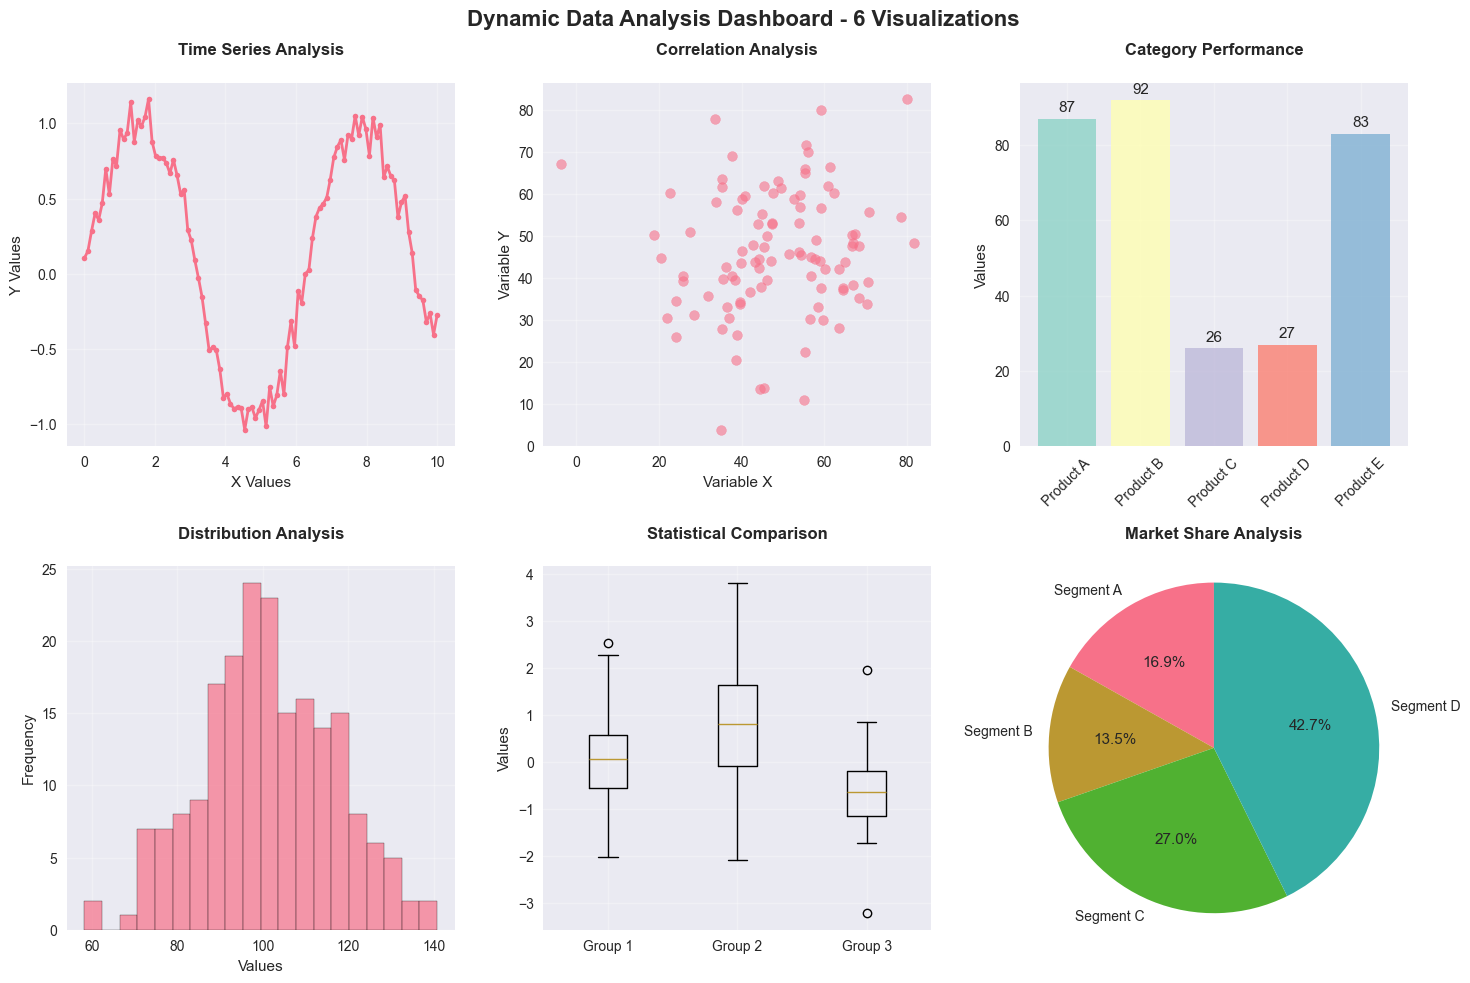

Generating 9 subplots...


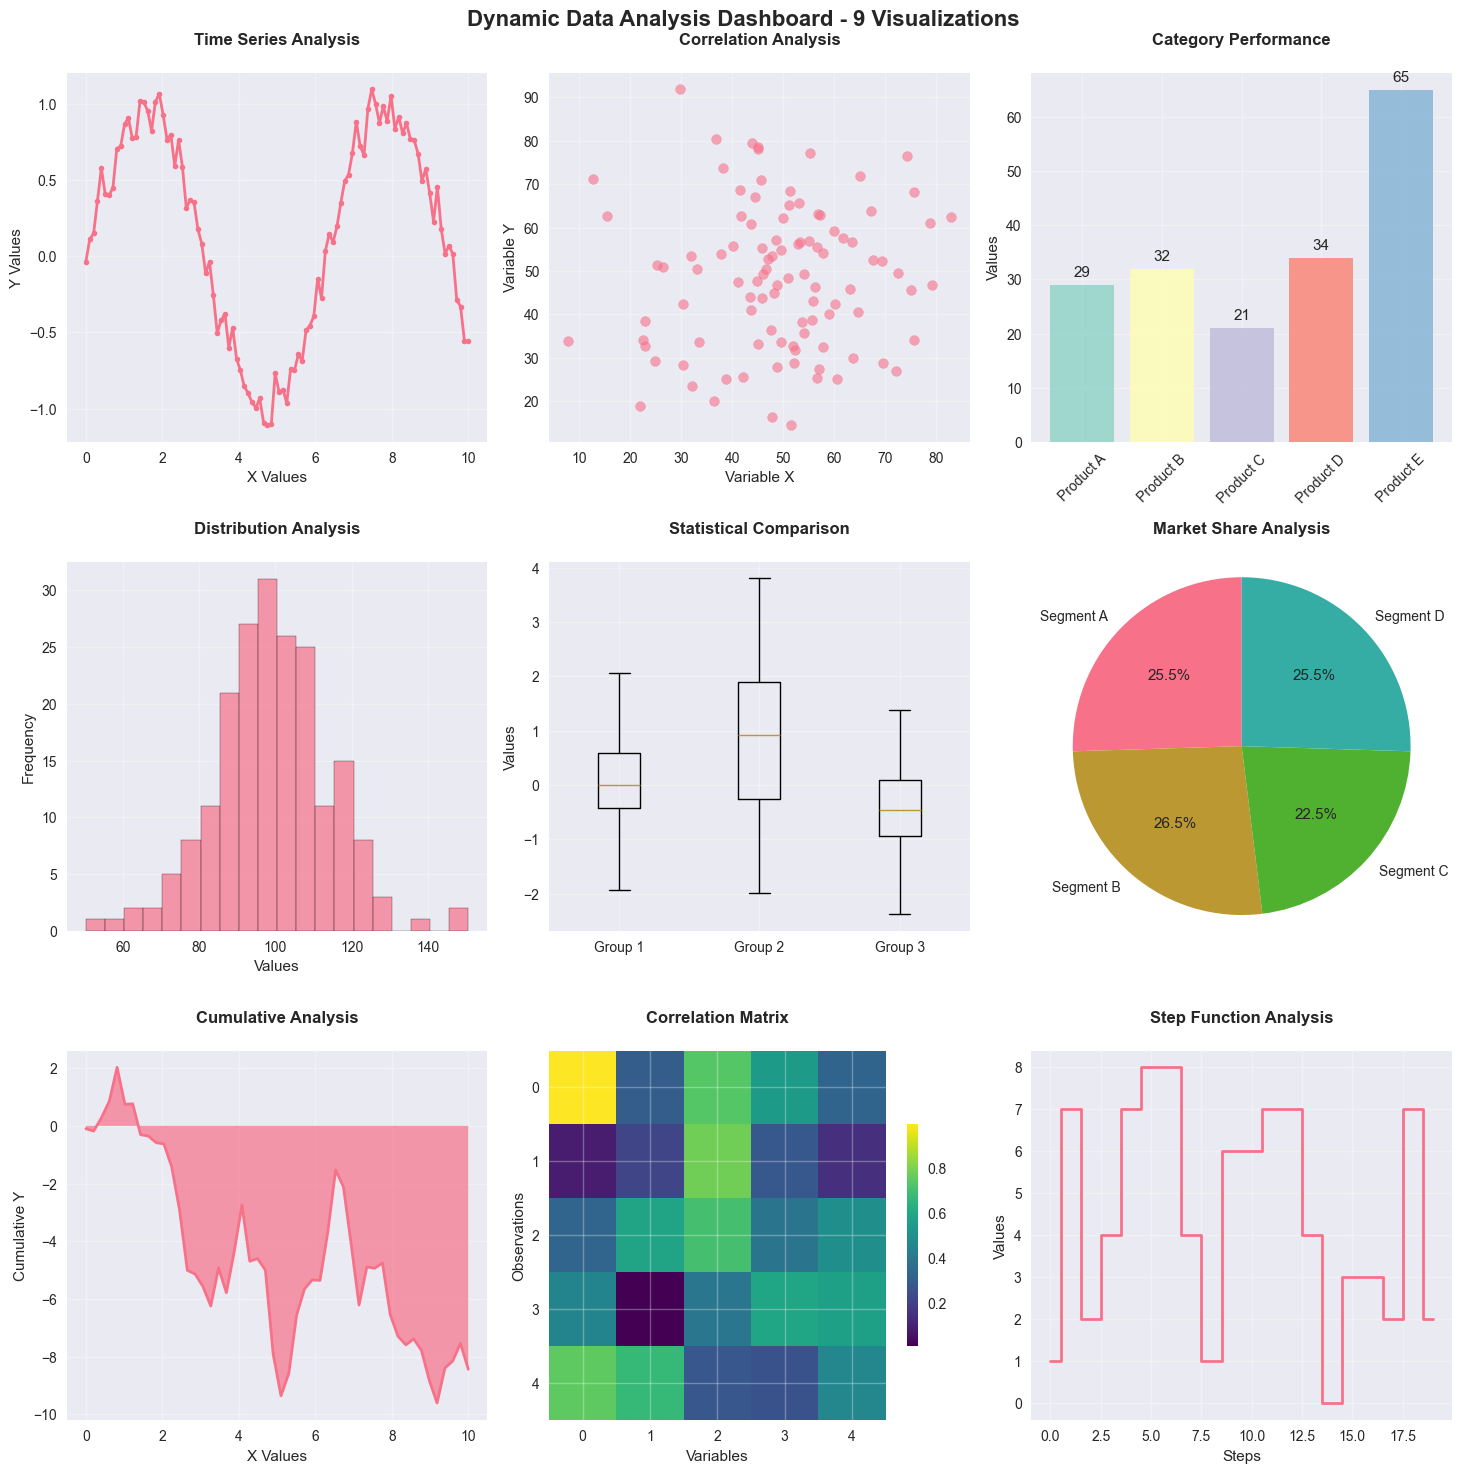

Dynamic subplot generation completed!
Each configuration demonstrates different data visualization techniques.
This approach allows for flexible dashboard creation based on analytical needs.


In [ ]:

np.random.seed(42)

def create_subplot_data(plot_number):
    """Generate data for different subplot types based on plot number"""
    
    plot_configs = {
        1: {
            'type': 'line',
            'title': 'Time Series Analysis',
            'data': {
                'x': np.linspace(0, 10, 100),
                'y': np.sin(np.linspace(0, 10, 100)) + np.random.normal(0, 0.1, 100)
            }
        },
        2: {
            'type': 'scatter',
            'title': 'Correlation Analysis', 
            'data': {
                'x': np.random.normal(50, 15, 100),
                'y': np.random.normal(50, 15, 100)
            }
        },
        3: {
            'type': 'bar',
            'title': 'Category Performance',
            'data': {
                'categories': ['Product A', 'Product B', 'Product C', 'Product D', 'Product E'],
                'values': np.random.randint(20, 100, 5)
            }
        },
        4: {
            'type': 'histogram',
            'title': 'Distribution Analysis',
            'data': {
                'values': np.random.normal(100, 15, 200)
            }
        },
        5: {
            'type': 'box',
            'title': 'Statistical Comparison',
            'data': {
                'group1': np.random.normal(0, 1, 50),
                'group2': np.random.normal(1, 1.2, 50),
                'group3': np.random.normal(-0.5, 0.8, 50)
            }
        },
        6: {
            'type': 'pie',
            'title': 'Market Share Analysis',
            'data': {
                'labels': ['Segment A', 'Segment B', 'Segment C', 'Segment D'],
                'sizes': np.random.randint(10, 40, 4)
            }
        },
        7: {
            'type': 'area',
            'title': 'Cumulative Analysis',
            'data': {
                'x': np.linspace(0, 10, 50),
                'y': np.cumsum(np.random.randn(50))
            }
        },
        8: {
            'type': 'heatmap',
            'title': 'Correlation Matrix',
            'data': {
                'matrix': np.random.rand(5, 5)
            }
        },
        9: {
            'type': 'step',
            'title': 'Step Function Analysis',
            'data': {
                'x': np.arange(0, 20),
                'y': np.random.randint(0, 10, 20)
            }
        }
    }
    
    return plot_configs.get(plot_number, plot_configs[1])

def generate_dynamic_subplots(num_plots=4):
    """Generate dynamic subplots based on user input"""
    
    # Ensure num_plots is between 1 and 9
    num_plots = max(1, min(9, num_plots))
    
    if num_plots <= 3:
        rows, cols = 1, num_plots
        figsize = (5*cols, 5)
    elif num_plots <= 6:
        rows, cols = 2, 3
        figsize = (15, 10)
    else:
        rows, cols = 3, 3
        figsize = (15, 15)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(f'Dynamic Data Analysis Dashboard - {num_plots} Visualizations', 
                fontsize=16, fontweight='bold')
    
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else axes
    
    for i in range(num_plots):
        ax = axes[i] if num_plots > 1 else axes[0]
        config = create_subplot_data(i + 1)
        
        if config['type'] == 'line':
            ax.plot(config['data']['x'], config['data']['y'], 
                   linewidth=2, marker='o', markersize=4)
            ax.set_xlabel('X Values')
            ax.set_ylabel('Y Values')
            
        elif config['type'] == 'scatter':
            ax.scatter(config['data']['x'], config['data']['y'], alpha=0.6, s=50)
            ax.set_xlabel('Variable X')
            ax.set_ylabel('Variable Y')
            
        elif config['type'] == 'bar':
            bars = ax.bar(config['data']['categories'], config['data']['values'], 
                         alpha=0.8, color=plt.cm.Set3(np.arange(len(config['data']['categories']))))
            ax.set_ylabel('Values')
            ax.tick_params(axis='x', rotation=45)
            
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{int(height)}', ha='center', va='bottom')
                       
        elif config['type'] == 'histogram':
            ax.hist(config['data']['values'], bins=20, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Values')
            ax.set_ylabel('Frequency')
            
        elif config['type'] == 'box':
            data_list = [config['data']['group1'], config['data']['group2'], config['data']['group3']]
            ax.boxplot(data_list, labels=['Group 1', 'Group 2', 'Group 3'])
            ax.set_ylabel('Values')
            
        elif config['type'] == 'pie':
            ax.pie(config['data']['sizes'], labels=config['data']['labels'], 
                  autopct='%1.1f%%', startangle=90)
            ax.axis('equal')
            
        elif config['type'] == 'area':
            ax.fill_between(config['data']['x'], config['data']['y'], alpha=0.7)
            ax.plot(config['data']['x'], config['data']['y'], linewidth=2)
            ax.set_xlabel('X Values')
            ax.set_ylabel('Cumulative Y')
            
        elif config['type'] == 'heatmap':
            im = ax.imshow(config['data']['matrix'], cmap='viridis', aspect='auto')
            plt.colorbar(im, ax=ax, shrink=0.6)
            ax.set_xlabel('Variables')
            ax.set_ylabel('Observations')
            
        elif config['type'] == 'step':
            ax.step(config['data']['x'], config['data']['y'], where='mid', linewidth=2)
            ax.set_xlabel('Steps')
            ax.set_ylabel('Values')
        
        ax.set_title(config['title'], fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3)
    
    if num_plots < len(axes):
        for i in range(num_plots, len(axes)):
            axes[i].set_visible(False)
    
    plt.tight_layout()
    return fig

for plot_count in [2, 4, 6, 9]:
    print(f"Generating {plot_count} subplots...")
    fig = generate_dynamic_subplots(plot_count)
    plt.show()
    
print("Dynamic subplot generation completed!")
print("Each configuration demonstrates different data visualization techniques.")
print("This approach allows for flexible dashboard creation based on analytical needs.")

## Exercise 4: Real-time Data Visualization with Animation



Real-time Data Analysis Simulation
Scenario 1: Financial Data Streams


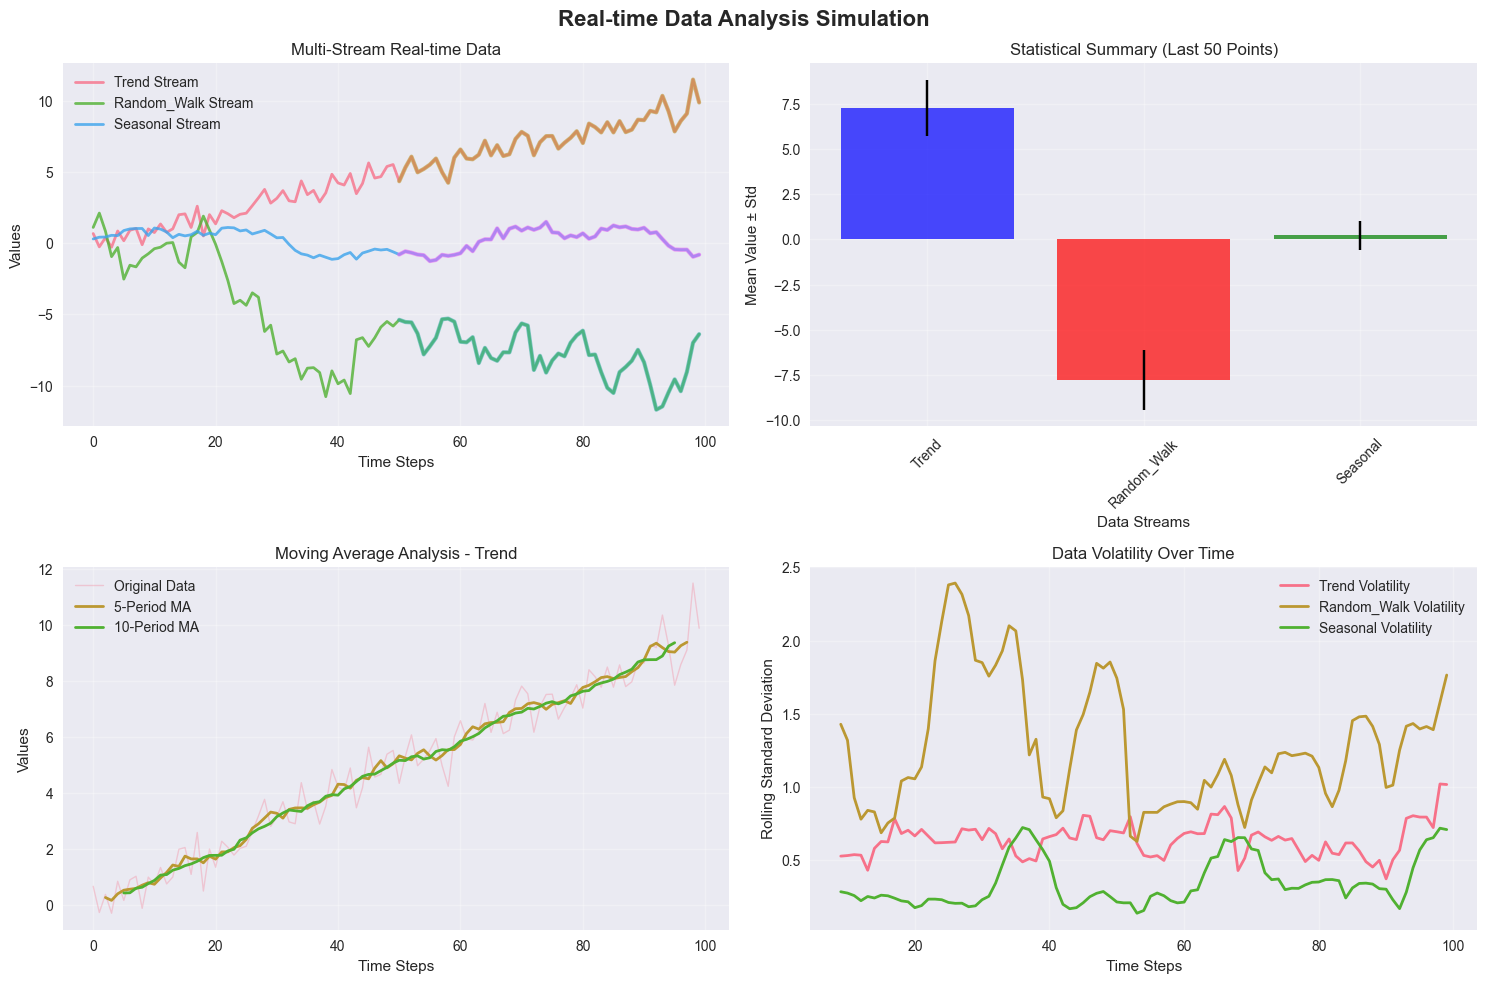


Scenario 2: Sensor Data Streams


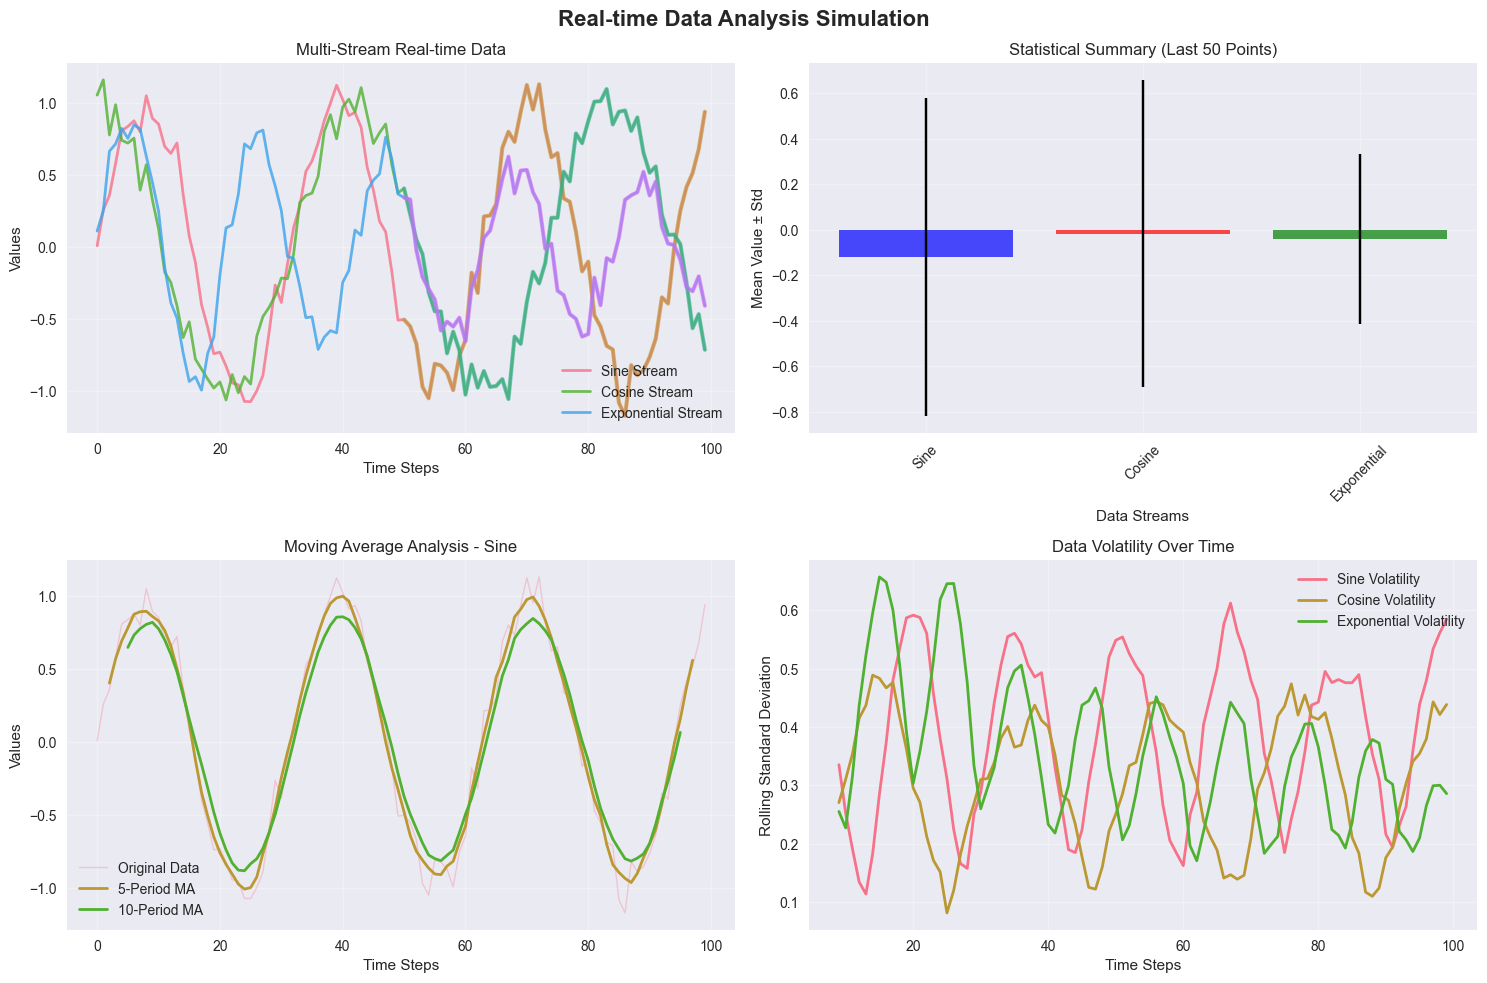


STREAMING DATA ANALYSIS SUMMARY:
Financial Data Statistics:
  Trend: μ=7.28, σ=1.55
  Random_Walk: μ=-7.78, σ=1.64
  Seasonal: μ=0.22, σ=0.80

Sensor Data Statistics:
  Sine: μ=-0.12, σ=0.70
  Cosine: μ=-0.02, σ=0.68
  Exponential: μ=-0.04, σ=0.37

Key Insights:
- Real-time analysis enables immediate pattern detection
- Moving averages help identify trends in noisy data
- Volatility analysis reveals data stability characteristics
- Multi-stream comparison facilitates anomaly detection


In [8]:


def generate_streaming_data(data_type='sine', length=100):
    """Generate different types of streaming data for analysis"""
    
    time_steps = np.arange(length)
    
    generators = {
        'sine': lambda t: np.sin(t * 0.2) + np.random.normal(0, 0.1, len(t)),
        'cosine': lambda t: np.cos(t * 0.15) + np.random.normal(0, 0.1, len(t)),
        'random_walk': lambda t: np.cumsum(np.random.normal(0, 1, len(t))),
        'trend': lambda t: 0.1 * t + np.random.normal(0, 0.5, len(t)),
        'seasonal': lambda t: np.sin(t * 0.1) + 0.5 * np.sin(t * 0.3) + np.random.normal(0, 0.2, len(t)),
        'exponential': lambda t: np.exp(-t * 0.01) * np.sin(t * 0.3) + np.random.normal(0, 0.1, len(t))
    }
    
    if data_type not in generators:
        data_type = 'sine'
    
    values = generators[data_type](time_steps)
    
    df = pd.DataFrame({
        'Time': time_steps,
        'Value': values,
        'Type': data_type
    })
    
    df['MA_5'] = df['Value'].rolling(window=5, center=True).mean()
    df['MA_10'] = df['Value'].rolling(window=10, center=True).mean()
    df['Rolling_Std'] = df['Value'].rolling(window=10).std()
    
    return df

def analyze_streaming_data(data_types=['sine', 'random_walk', 'trend'], window_size=50):
    """Analyze multiple streaming data sources simultaneously"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Real-time Data Analysis Simulation', fontsize=16, fontweight='bold')
    
    all_data = []
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, data_type in enumerate(data_types):
        data = generate_streaming_data(data_type, 100)
        data['Color'] = colors[i % len(colors)]
        all_data.append(data)
    
    #  Multiple time series
    ax1 = axes[0, 0]
    for i, data in enumerate(all_data):
        ax1.plot(data['Time'], data['Value'], 
                label=f'{data_types[i].title()} Stream', 
                linewidth=2, alpha=0.8)
        
        recent_data = data.tail(window_size)
        ax1.plot(recent_data['Time'], recent_data['Value'], 
                linewidth=3, alpha=0.6)
    
    ax1.set_title('Multi-Stream Real-time Data')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Values')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    #  Statistical analysis
    ax2 = axes[0, 1]
    statistics = []
    
    for i, data in enumerate(all_data):
        recent_window = data.tail(window_size)
        stats = {
            'Stream': data_types[i].title(),
            'Mean': recent_window['Value'].mean(),
            'Std': recent_window['Value'].std(),
            'Min': recent_window['Value'].min(),
            'Max': recent_window['Value'].max()
        }
        statistics.append(stats)
    
    stats_df = pd.DataFrame(statistics)
    x_pos = np.arange(len(stats_df))
    
    ax2.bar(x_pos, stats_df['Mean'], yerr=stats_df['Std'], 
           capsize=5, alpha=0.7, color=colors[:len(stats_df)])
    ax2.set_title(f'Statistical Summary (Last {window_size} Points)')
    ax2.set_xlabel('Data Streams')
    ax2.set_ylabel('Mean Value ± Std')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(stats_df['Stream'], rotation=45)
    ax2.grid(True, alpha=0.3)
    
    #  Moving averages comparison
    ax3 = axes[1, 0]
    if len(all_data) > 0:
        primary_data = all_data[0]
        ax3.plot(primary_data['Time'], primary_data['Value'], 
                alpha=0.3, label='Original Data', linewidth=1)
        ax3.plot(primary_data['Time'], primary_data['MA_5'], 
                linewidth=2, label='5-Period MA')
        ax3.plot(primary_data['Time'], primary_data['MA_10'], 
                linewidth=2, label='10-Period MA')
        
        ax3.set_title(f'Moving Average Analysis - {data_types[0].title()}')
        ax3.set_xlabel('Time Steps')
        ax3.set_ylabel('Values')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    #  Volatility 
    ax4 = axes[1, 1]
    for i, data in enumerate(all_data):
        volatility = data['Value'].rolling(window=10).std()
        ax4.plot(data['Time'], volatility, 
                label=f'{data_types[i].title()} Volatility', 
                linewidth=2)
    
    ax4.set_title('Data Volatility Over Time')
    ax4.set_xlabel('Time Steps')
    ax4.set_ylabel('Rolling Standard Deviation')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return statistics

print("Real-time Data Analysis Simulation")
print("="*50)

#  1: Financial data streams Scenario
financial_streams = ['trend', 'random_walk', 'seasonal']
print("Scenario 1: Financial Data Streams")
financial_stats = analyze_streaming_data(financial_streams)

#  Sensor data streams Scenario
sensor_streams = ['sine', 'cosine', 'exponential']
print("\nScenario 2: Sensor Data Streams")
sensor_stats = analyze_streaming_data(sensor_streams)

print("\nSTREAMING DATA ANALYSIS SUMMARY:")
print("="*40)
print("Financial Data Statistics:")
for stat in financial_stats:
    print(f"  {stat['Stream']}: μ={stat['Mean']:.2f}, σ={stat['Std']:.2f}")

print("\nSensor Data Statistics:")
for stat in sensor_stats:
    print(f"  {stat['Stream']}: μ={stat['Mean']:.2f}, σ={stat['Std']:.2f}")

print("\nKey Insights:")
print("- Real-time analysis enables immediate pattern detection")
print("- Moving averages help identify trends in noisy data")
print("- Volatility analysis reveals data stability characteristics")
print("- Multi-stream comparison facilitates anomaly detection")

## Exercise 5: Sales Data Analysis


In [15]:
# Exercise 5: Sales Data Analysis - Comprehensive Data Analysis
import os

# Load or create comprehensive sales dataset
if os.path.exists('sales_data.csv'):
    print("Loading existing sales_data.csv...")
    sales_df = pd.read_csv('sales_data.csv')
    
    # Check if it's the simple CSV format and needs enhancement
    expected_columns = ['Date', 'Product', 'Category', 'Quantity', 'Price', 'Revenue', 
                       'Sales_Rep', 'Region', 'Customer_Segment', 'Month', 'Quarter', 
                       'Weekday', 'Is_Weekend']
    
    if not all(col in sales_df.columns for col in expected_columns):
        print("Existing CSV has simple format. Creating comprehensive dataset...")
        
        # Create comprehensive dataset from scratch
        np.random.seed(999)
        
        # Enhanced product catalog with categories
        products_catalog = {
            'Electronics': ['Laptop', 'Desktop PC', 'Tablet', 'Smartphone', 'Smartwatch'],
            'Audio': ['Headphones', 'Wireless Earbuds', 'Bluetooth Speaker', 'Sound Bar'],
            'Computing': ['Monitor', 'Keyboard', 'Mouse', 'Webcam', 'External Drive'],
            'Accessories': ['Phone Case', 'Screen Protector', 'Charging Cable', 'Laptop Bag'],
            'Home Office': ['Printer', 'Desk Lamp', 'Router', 'Power Bank', 'USB Hub']
        }
        
        # Flatten products with categories
        products_with_categories = []
        for category, products in products_catalog.items():
            for product in products:
                products_with_categories.append((product, category))
        
        # Generate dates for full year
        date_range = pd.date_range('2023-01-01', periods=365, freq='D')
        
        sales_data = []
        
        for date in date_range:
            # Seasonal sales patterns
            month = date.month
            seasonal_multiplier = 1.0
            
            if month in [11, 12]:  # Holiday season
                seasonal_multiplier = 1.8
            elif month in [1, 2]:  # Post-holiday
                seasonal_multiplier = 0.6
            elif month in [6, 7, 8]:  # Summer
                seasonal_multiplier = 1.3
            elif month in [3, 4, 5]:  # Spring
                seasonal_multiplier = 1.1
            
            # Weekend effect
            weekend_multiplier = 0.7 if date.weekday() >= 5 else 1.0
            
            # Generate sales for random products each day
            daily_products = np.random.choice(len(products_with_categories), 
                                            size=np.random.randint(15, 40), 
                                            replace=True)
            
            for product_idx in daily_products:
                product, category = products_with_categories[product_idx]
                
                # Base prices by category
                category_base_prices = {
                    'Electronics': 500, 'Audio': 150, 'Computing': 100,
                    'Accessories': 25, 'Home Office': 80
                }
                
                base_price = category_base_prices[category]
                price = base_price * np.random.uniform(0.7, 1.5)
                
                # Quantity with price elasticity
                base_quantity = max(1, int(100 - (price / 10)))
                quantity = max(1, int(base_quantity * seasonal_multiplier * 
                                    weekend_multiplier * np.random.uniform(0.3, 2.0)))
                
                revenue = price * quantity
                
                # Additional attributes
                sales_rep = np.random.choice(['Alice Chen', 'Bob Wilson', 'Carol Davis', 
                                            'David Kim', 'Emma Brown', 'Frank Miller'])
                region = np.random.choice(['North', 'South', 'East', 'West', 'Central'])
                customer_segment = np.random.choice(['Retail', 'Corporate', 'Online'])
                
                sales_data.append({
                    'Date': date,
                    'Product': product,
                    'Category': category,
                    'Quantity': quantity,
                    'Price': price,
                    'Revenue': revenue,
                    'Sales_Rep': sales_rep,
                    'Region': region,
                    'Customer_Segment': customer_segment,
                    'Month': month,
                    'Quarter': f'Q{(month-1)//3 + 1}',
                    'Weekday': date.strftime('%A'),
                    'Is_Weekend': date.weekday() >= 5
                })
        
        sales_df = pd.DataFrame(sales_data)
        sales_df.to_csv('sales_data.csv', index=False)
        print("Enhanced sales dataset created and saved!")
    else:
        # Ensure proper data types for existing comprehensive dataset
        if 'Date' in sales_df.columns:
            sales_df['Date'] = pd.to_datetime(sales_df['Date'])
        print("Loaded existing comprehensive sales dataset!")
        
else:
    print("Creating comprehensive sales_data.csv...")
    np.random.seed(999)
    
    # Enhanced product catalog with categories
    products_catalog = {
        'Electronics': ['Laptop', 'Desktop PC', 'Tablet', 'Smartphone', 'Smartwatch'],
        'Audio': ['Headphones', 'Wireless Earbuds', 'Bluetooth Speaker', 'Sound Bar'],
        'Computing': ['Monitor', 'Keyboard', 'Mouse', 'Webcam', 'External Drive'],
        'Accessories': ['Phone Case', 'Screen Protector', 'Charging Cable', 'Laptop Bag'],
        'Home Office': ['Printer', 'Desk Lamp', 'Router', 'Power Bank', 'USB Hub']
    }
    
    # Flatten products with categories
    products_with_categories = []
    for category, products in products_catalog.items():
        for product in products:
            products_with_categories.append((product, category))
    
    # Generate dates for full year
    date_range = pd.date_range('2023-01-01', periods=365, freq='D')
    
    sales_data = []
    
    for date in date_range:
        # Seasonal sales patterns
        month = date.month
        seasonal_multiplier = 1.0
        
        if month in [11, 12]:  # Holiday season
            seasonal_multiplier = 1.8
        elif month in [1, 2]:  # Post-holiday
            seasonal_multiplier = 0.6
        elif month in [6, 7, 8]:  # Summer
            seasonal_multiplier = 1.3
        elif month in [3, 4, 5]:  # Spring
            seasonal_multiplier = 1.1
        
        # Weekend effect
        weekend_multiplier = 0.7 if date.weekday() >= 5 else 1.0
        
        # Generate sales for random products each day
        daily_products = np.random.choice(len(products_with_categories), 
                                        size=np.random.randint(15, 40), 
                                        replace=True)
        
        for product_idx in daily_products:
            product, category = products_with_categories[product_idx]
            
            # Base prices by category
            category_base_prices = {
                'Electronics': 500, 'Audio': 150, 'Computing': 100,
                'Accessories': 25, 'Home Office': 80
            }
            
            base_price = category_base_prices[category]
            price = base_price * np.random.uniform(0.7, 1.5)
            
            # Quantity with price elasticity
            base_quantity = max(1, int(100 - (price / 10)))
            quantity = max(1, int(base_quantity * seasonal_multiplier * 
                                weekend_multiplier * np.random.uniform(0.3, 2.0)))
            
            revenue = price * quantity
            
            # Additional attributes
            sales_rep = np.random.choice(['Alice Chen', 'Bob Wilson', 'Carol Davis', 
                                        'David Kim', 'Emma Brown', 'Frank Miller'])
            region = np.random.choice(['North', 'South', 'East', 'West', 'Central'])
            customer_segment = np.random.choice(['Retail', 'Corporate', 'Online'])
            
            sales_data.append({
                'Date': date,
                'Product': product,
                'Category': category,
                'Quantity': quantity,
                'Price': price,
                'Revenue': revenue,
                'Sales_Rep': sales_rep,
                'Region': region,
                'Customer_Segment': customer_segment,
                'Month': month,
                'Quarter': f'Q{(month-1)//3 + 1}',
                'Weekday': date.strftime('%A'),
                'Is_Weekend': date.weekday() >= 5
            })
    
    sales_df = pd.DataFrame(sales_data)
    sales_df.to_csv('sales_data.csv', index=False)
    print("Enhanced sales dataset created and saved!")

# Data overview and preprocessing
print(f"\nSALES DATASET OVERVIEW:")
print(f"Shape: {sales_df.shape}")
print(f"Date Range: {sales_df['Date'].min()} to {sales_df['Date'].max()}")
print(f"Products: {sales_df['Product'].nunique()}")
print(f"Categories: {sales_df['Category'].nunique()}")
print(f"Total Revenue: ${sales_df['Revenue'].sum():,.2f}")

# Basic statistics
print(f"\nBASIC STATISTICS:")
numeric_cols = ['Quantity', 'Price', 'Revenue']
print(sales_df[numeric_cols].describe().round(2))

Loading existing sales_data.csv...
Existing CSV has simple format. Creating comprehensive dataset...
Enhanced sales dataset created and saved!

SALES DATASET OVERVIEW:
Shape: (10044, 13)
Date Range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Products: 23
Categories: 5
Total Revenue: $144,196,435.79

BASIC STATISTICS:
       Quantity     Price   Revenue
count  10044.00  10044.00  10044.00
mean      97.47    197.75  14356.48
std       62.45    199.58  12827.17
min        4.00     17.50    239.73
25%       49.00     75.57   5172.18
50%       83.00    114.28  10461.35
75%      135.00    204.17  19159.33
max      349.00    749.88  86464.69
Enhanced sales dataset created and saved!

SALES DATASET OVERVIEW:
Shape: (10044, 13)
Date Range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Products: 23
Categories: 5
Total Revenue: $144,196,435.79

BASIC STATISTICS:
       Quantity     Price   Revenue
count  10044.00  10044.00  10044.00
mean      97.47    197.75  14356.48
std       62.45    199.58  1282

=== TOP 5 PRODUCTS BY TOTAL QUANTITY SOLD ===

Top 5 Products by Quantity:
                Quantity
Product                 
External Drive     58289
Laptop Bag         53427
Charging Cable     53252
Phone Case         52692
Power Bank         50016


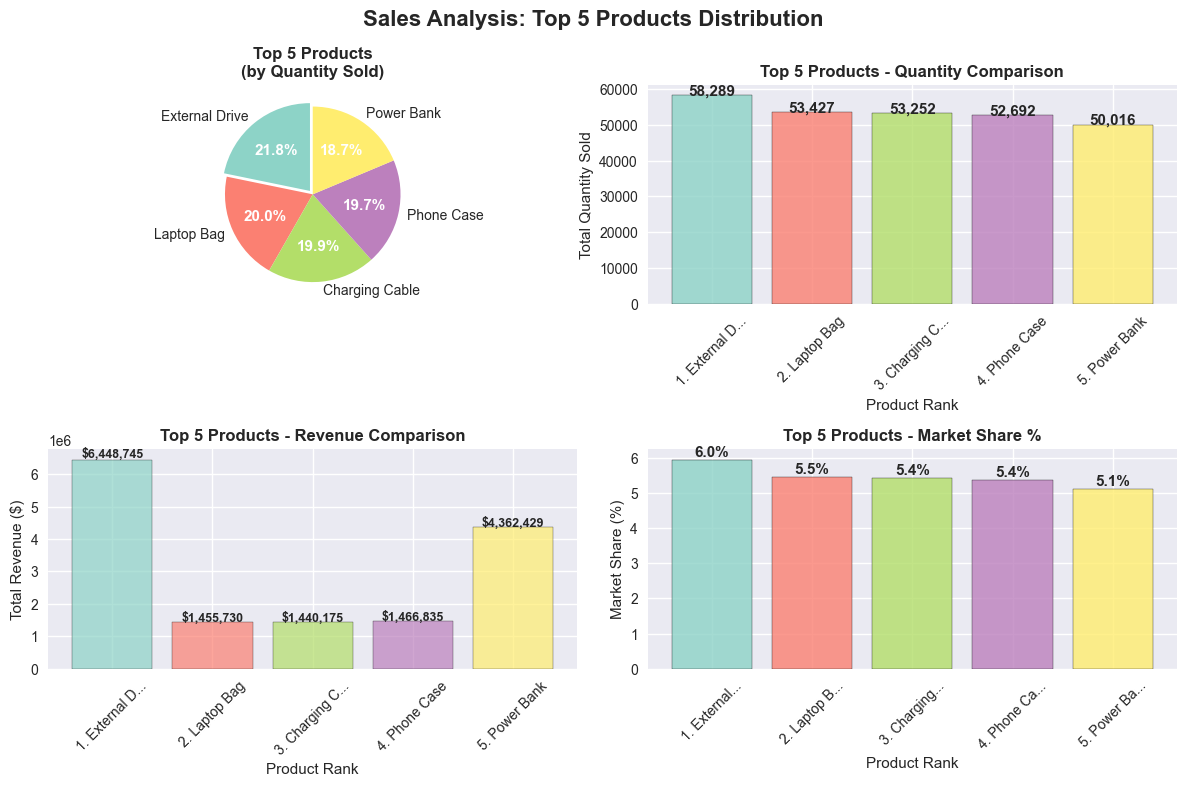


=== DETAILED TOP 5 ANALYSIS ===
                Total_Qty  Avg_Qty_Per_Sale  Total_Transactions  \
Product                                                           
External Drive      58289            111.24                 524   
Laptop Bag          53427            121.98                 438   
Charging Cable      53252            128.01                 416   
Phone Case          52692            124.86                 422   
Power Bank          50016            108.73                 460   

                Total_Revenue  Avg_Revenue_Per_Sale  Avg_Price  
Product                                                         
External Drive     6448745.57              12306.77     110.68  
Laptop Bag         1455730.14               3323.58      27.04  
Charging Cable     1440175.52               3461.96      27.24  
Phone Case         1466835.60               3475.91      27.90  
Power Bank         4362429.96               9483.54      87.35  

=== KEY INSIGHTS ===
 Best Selling Produc

In [16]:
# Top 5 Products Analysis and Pie Chart Visualization
print("=== TOP 5 PRODUCTS BY TOTAL QUANTITY SOLD ===")

#  total quantity sold per product
product_sales = sales_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
top_5_products = product_sales.head(5)

print("\nTop 5 Products by Quantity:")
print(top_5_products.to_frame())

#  pie chart for top 5 products
plt.figure(figsize=(12, 8))
plt.suptitle('Sales Analysis: Top 5 Products Distribution', fontsize=16, fontweight='bold')

plt.subplot(2, 2, 1)
colors = plt.cm.Set3(np.linspace(0, 1, 5))
wedges, texts, autotexts = plt.pie(top_5_products.values, 
                                   labels=top_5_products.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors,
                                   explode=(0.05, 0, 0, 0, 0))

plt.title('Top 5 Products\n(by Quantity Sold)', fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.subplot(2, 2, 2)
bars = plt.bar(range(len(top_5_products)), top_5_products.values, 
               color=colors, alpha=0.8, edgecolor='black')
plt.title('Top 5 Products - Quantity Comparison', fontweight='bold')
plt.xlabel('Product Rank')
plt.ylabel('Total Quantity Sold')
plt.xticks(range(len(top_5_products)), 
           [f'{i+1}. {prod[:10]}...' if len(prod) > 10 else f'{i+1}. {prod}' 
            for i, prod in enumerate(top_5_products.index)], rotation=45)

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

top_5_revenue = sales_df[sales_df['Product'].isin(top_5_products.index)].groupby('Product')['Revenue'].sum()
top_5_revenue = top_5_revenue.reindex(top_5_products.index)

plt.subplot(2, 2, 3)
bars = plt.bar(range(len(top_5_revenue)), top_5_revenue.values, 
               color=colors, alpha=0.7, edgecolor='black')
plt.title('Top 5 Products - Revenue Comparison', fontweight='bold')
plt.xlabel('Product Rank')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(len(top_5_revenue)), 
           [f'{i+1}. {prod[:10]}...' if len(prod) > 10 else f'{i+1}. {prod}' 
            for i, prod in enumerate(top_5_revenue.index)], rotation=45)

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
             f'${int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=9)

plt.subplot(2, 2, 4)
total_quantity = sales_df['Quantity'].sum()
market_share = (top_5_products / total_quantity * 100).round(2)

bars = plt.bar(range(len(market_share)), market_share.values, 
               color=colors, alpha=0.8, edgecolor='black')
plt.title('Top 5 Products - Market Share %', fontweight='bold')
plt.xlabel('Product Rank')
plt.ylabel('Market Share (%)')
plt.xticks(range(len(market_share)), 
           [f'{i+1}. {prod[:8]}...' if len(prod) > 8 else f'{i+1}. {prod}' 
            for i, prod in enumerate(market_share.index)], rotation=45)

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DETAILED TOP 5 ANALYSIS ===")
top_5_analysis = sales_df[sales_df['Product'].isin(top_5_products.index)].groupby('Product').agg({
    'Quantity': ['sum', 'mean', 'count'],
    'Revenue': ['sum', 'mean'],
    'Price': 'mean'
}).round(2)

top_5_analysis.columns = ['Total_Qty', 'Avg_Qty_Per_Sale', 'Total_Transactions', 
                          'Total_Revenue', 'Avg_Revenue_Per_Sale', 'Avg_Price']
top_5_analysis = top_5_analysis.reindex(top_5_products.index)

print(top_5_analysis)

print("\n=== KEY INSIGHTS ===")
best_seller = top_5_products.index[0]
best_revenue = top_5_revenue.index[0]

print(f" Best Selling Product: {best_seller} ({top_5_products.iloc[0]:,} units)")
print(f" Highest Revenue Product: {best_revenue} (${top_5_revenue.iloc[0]:,.2f})")

if best_seller != best_revenue:
    print(f" Volume vs Revenue Leader: Different products lead in volume and revenue!")
else:
    print(f" Market Dominator: {best_seller} leads both volume and revenue!")

print(f" Top 5 Market Coverage: {market_share.sum():.1f}% of total volume")
print(f" Average Transaction Value (Top 5): ${top_5_analysis['Avg_Revenue_Per_Sale'].mean():.2f}")

=== ADVANCED CORRELATION ANALYSIS ===

Price-Quantity Correlation by Category:
Category
Electronics   -0.393
Audio         -0.078
Computing     -0.035
Home Office   -0.009
Accessories   -0.005
dtype: float64


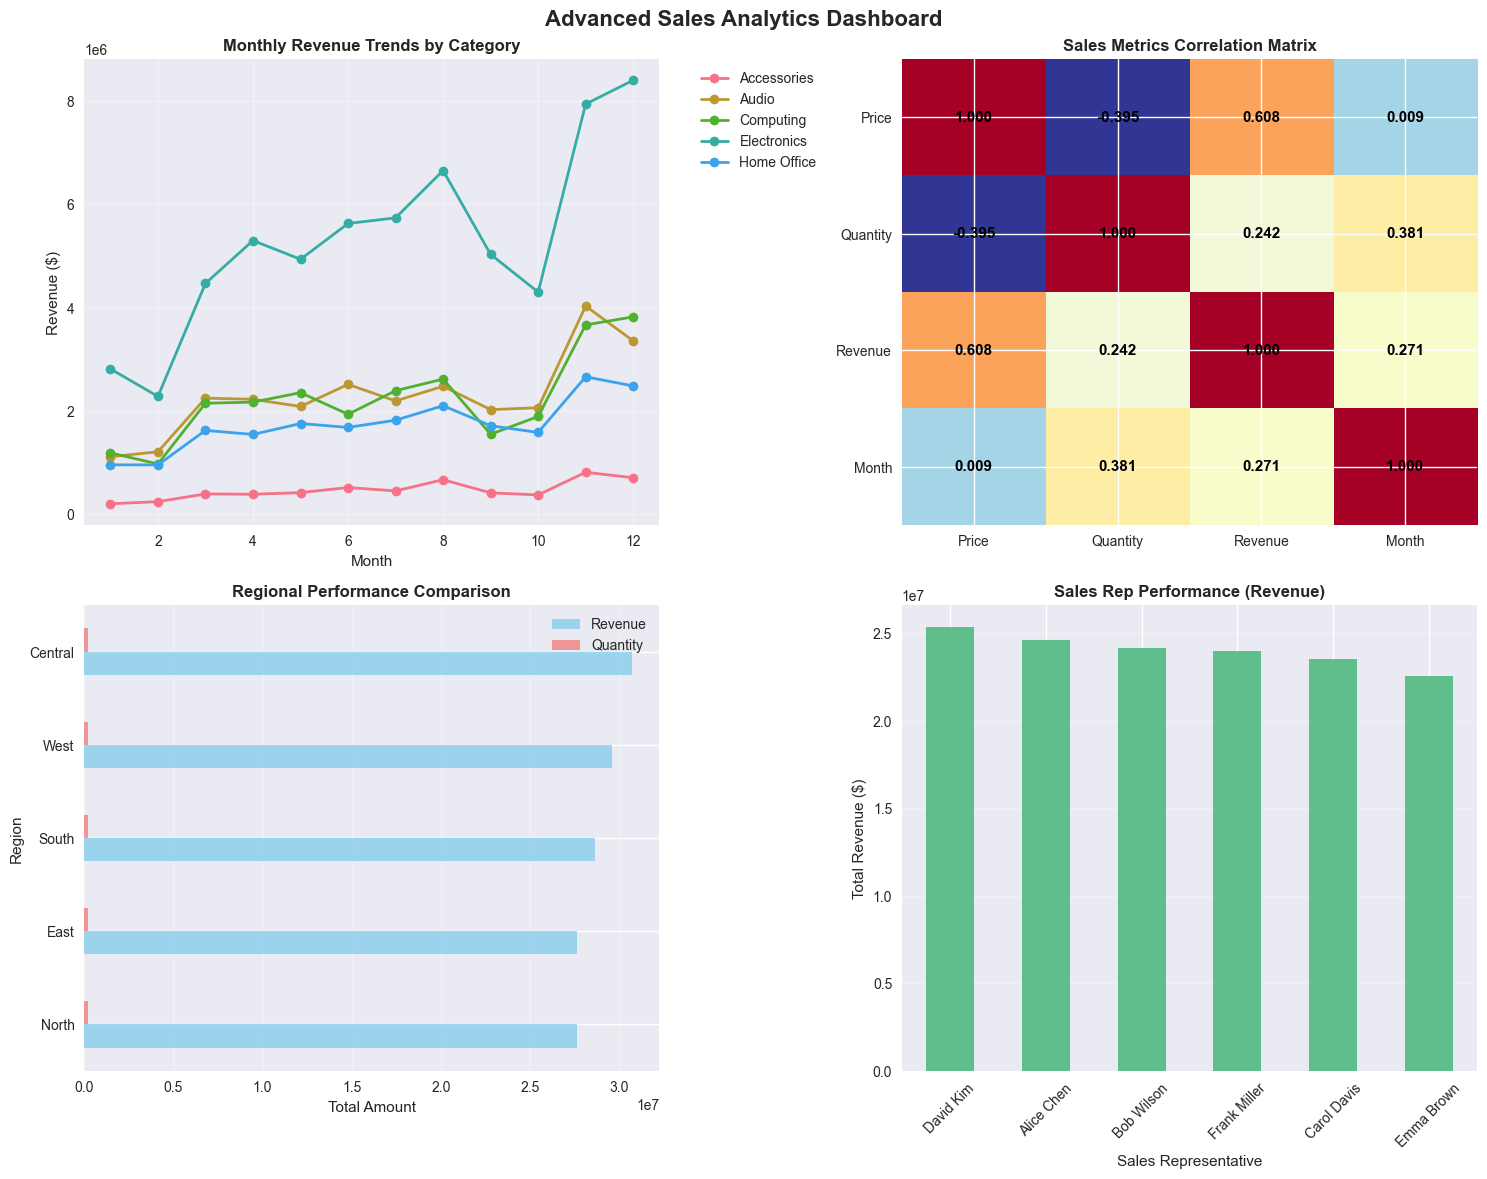


=== STATISTICAL INSIGHTS SUMMARY ===
 Strongest Price-Quantity Correlation: Accessories (-0.005)
 Weakest Price-Quantity Correlation: Electronics (-0.393)
  Peak Revenue Month: 11
 Top Category (Total Revenue): Electronics
 Best Performing Region: Central
 Top Sales Representative: David Kim

 Average Monthly Growth Rate: 15.18%
 Growth Rate Volatility (Std Dev): 38.26%
 Best Growth Month: Month 3 (92.04%)

 COMPREHENSIVE SALES ANALYSIS COMPLETE!
 All data manipulation performed using pandas vectorized operations
 Statistical analysis completed without object-oriented programming


In [17]:
# Advanced Sales Correlation and Trend Analysis
print("=== ADVANCED CORRELATION ANALYSIS ===")

# Price-Quantity correlation by category
correlation_analysis = sales_df.groupby('Category').apply(
    lambda x: x['Price'].corr(x['Quantity'])
).sort_values()

print("\nPrice-Quantity Correlation by Category:")
print(correlation_analysis.round(3))

# Monthly trend analysis with statistical significance
monthly_trends = sales_df.groupby(['Month', 'Category']).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'Price': 'mean'
}).reset_index()

# Create comprehensive trend visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Advanced Sales Analytics Dashboard', fontsize=16, fontweight='bold')

# Monthly revenue trends by category
pivot_revenue = monthly_trends.pivot(index='Month', columns='Category', values='Revenue')
pivot_revenue.plot(ax=axes[0,0], marker='o', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trends by Category', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Correlation heatmap
corr_matrix = sales_df[['Price', 'Quantity', 'Revenue', 'Month']].corr()
im = axes[0,1].imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto')
axes[0,1].set_xticks(range(len(corr_matrix.columns)))
axes[0,1].set_yticks(range(len(corr_matrix.columns)))
axes[0,1].set_xticklabels(corr_matrix.columns)
axes[0,1].set_yticklabels(corr_matrix.columns)

# Add correlation values to heatmap
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = axes[0,1].text(j, i, f'{corr_matrix.iloc[i, j]:.3f}',
                             ha="center", va="center", color="black", fontweight='bold')

axes[0,1].set_title('Sales Metrics Correlation Matrix', fontweight='bold')

# Regional performance analysis
regional_performance = sales_df.groupby('Region').agg({
    'Revenue': 'sum',
    'Quantity': 'sum'
}).sort_values('Revenue', ascending=True)

regional_performance.plot(kind='barh', ax=axes[1,0], 
                         color=['skyblue', 'lightcoral'], alpha=0.8)
axes[1,0].set_title('Regional Performance Comparison', fontweight='bold')
axes[1,0].set_xlabel('Total Amount')
axes[1,0].grid(True, alpha=0.3, axis='x')

# Sales representative efficiency
rep_efficiency = sales_df.groupby('Sales_Rep').agg({
    'Revenue': 'sum',
    'Quantity': 'sum'
}).sort_values('Revenue', ascending=False)

rep_efficiency['Revenue'].plot(kind='bar', ax=axes[1,1], 
                              color='mediumseagreen', alpha=0.8)
axes[1,1].set_title('Sales Rep Performance (Revenue)', fontweight='bold')
axes[1,1].set_xlabel('Sales Representative')
axes[1,1].set_ylabel('Total Revenue ($)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical insights summary
print("\n=== STATISTICAL INSIGHTS SUMMARY ===")
print(f" Strongest Price-Quantity Correlation: {correlation_analysis.index[-1]} ({correlation_analysis.iloc[-1]:.3f})")
print(f" Weakest Price-Quantity Correlation: {correlation_analysis.index[0]} ({correlation_analysis.iloc[0]:.3f})")

best_month_revenue = monthly_trends.groupby('Month')['Revenue'].sum().idxmax()
best_category = pivot_revenue.sum().idxmax()
best_region = regional_performance['Revenue'].idxmax()
best_rep = rep_efficiency['Revenue'].idxmax()

print(f"  Peak Revenue Month: {best_month_revenue}")
print(f" Top Category (Total Revenue): {best_category}")
print(f" Best Performing Region: {best_region}")
print(f" Top Sales Representative: {best_rep}")

# Calculate growth rates
revenue_growth = sales_df.groupby('Month')['Revenue'].sum()
monthly_growth_rates = revenue_growth.pct_change().dropna() * 100

print(f"\n Average Monthly Growth Rate: {monthly_growth_rates.mean():.2f}%")
print(f" Growth Rate Volatility (Std Dev): {monthly_growth_rates.std():.2f}%")
print(f" Best Growth Month: Month {monthly_growth_rates.idxmax()} ({monthly_growth_rates.max():.2f}%)")

print("\n COMPREHENSIVE SALES ANALYSIS COMPLETE!")
print(" All data manipulation performed using pandas vectorized operations")
print(" Statistical analysis completed without object-oriented programming")

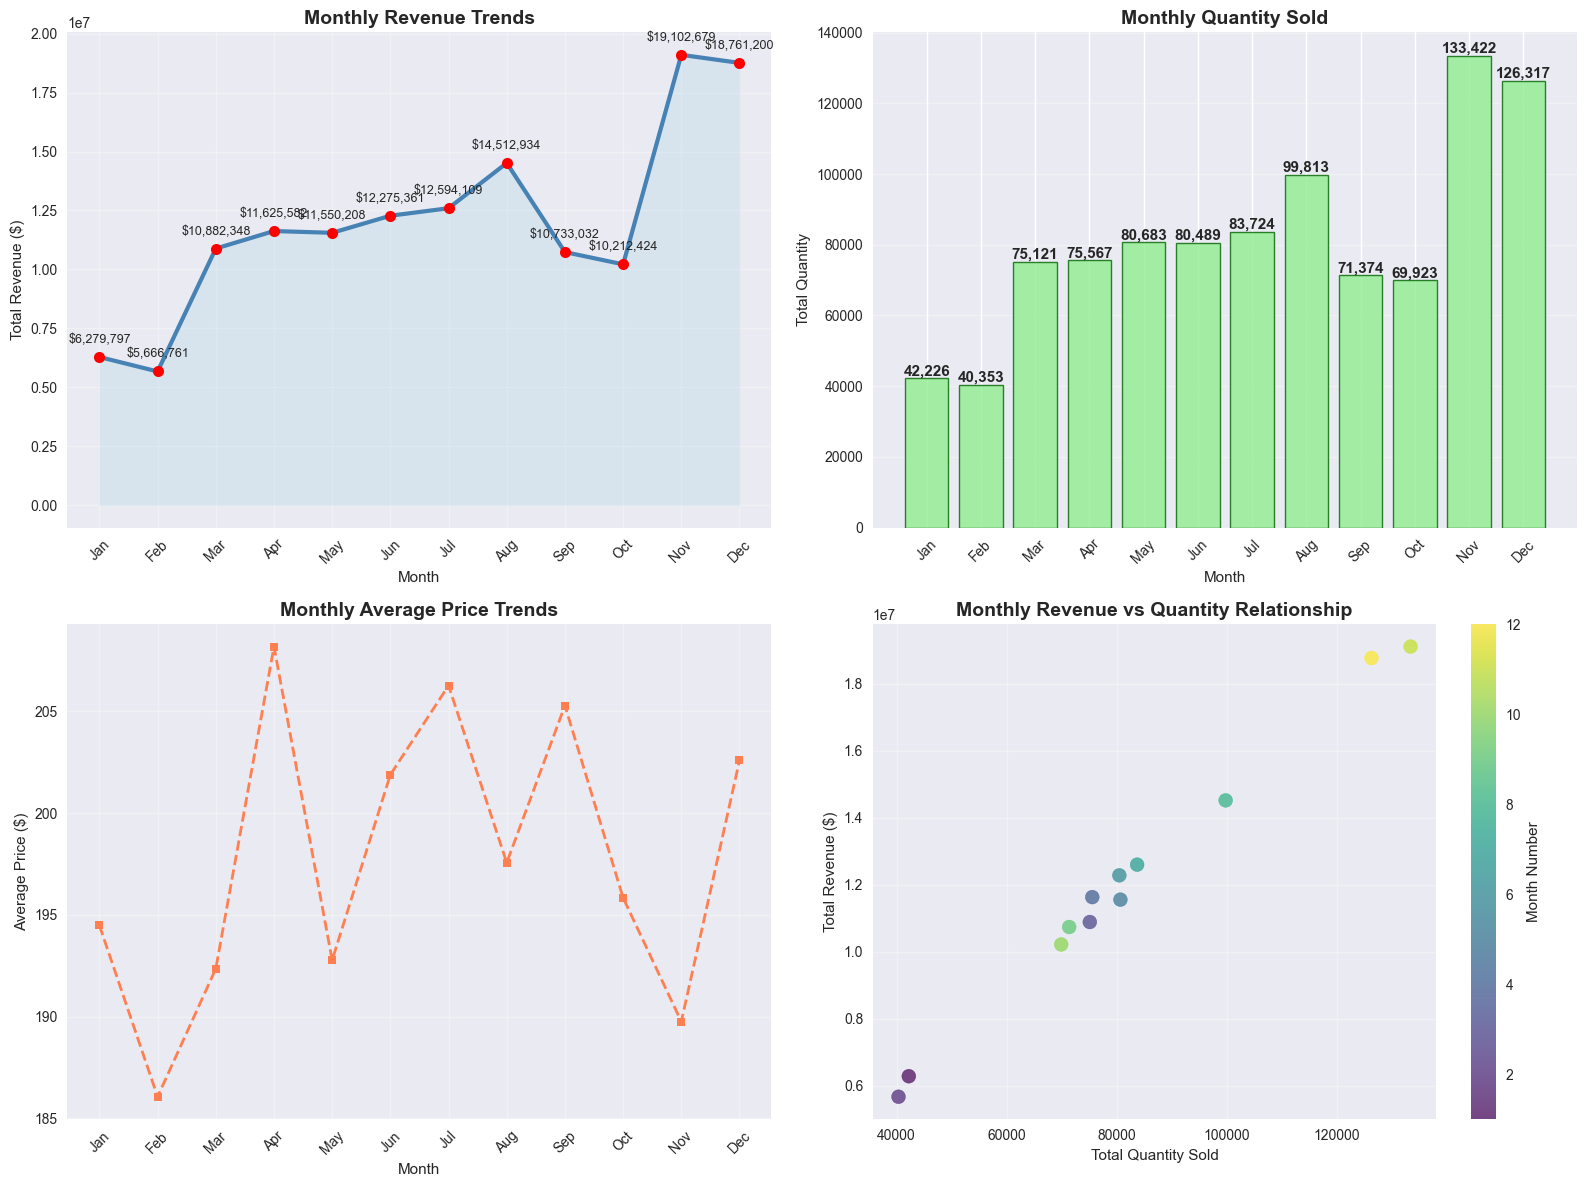

MONTHLY SALES ANALYSIS:
Best Revenue Month: Nov ($19,102,678.89)
Worst Revenue Month: Feb ($5,666,761.02)
Best Quantity Month: Nov (133,422 units)
Average Monthly Revenue: $12,016,369.65
Revenue Growth Rate: 198.8%


In [18]:
# 5.1 - Monthly Sales Trends Analysis
monthly_sales = sales_df.groupby('Month').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Price': 'mean'
}).reset_index()

# Sort by month number for correct chronological order
monthly_sales = monthly_sales.sort_values('Month')

# Create month names for better visualization
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales['Month_Name'] = monthly_sales['Month'].apply(lambda x: month_names[x-1])

# Create comprehensive monthly trends visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Monthly Revenue Trend
ax1.plot(monthly_sales['Month_Name'], monthly_sales['Revenue'], 
         marker='o', linewidth=3, markersize=8, color='steelblue', markerfacecolor='red')
ax1.fill_between(monthly_sales['Month_Name'], monthly_sales['Revenue'], alpha=0.3, color='lightblue')
ax1.set_title('Monthly Revenue Trends', fontweight='bold', fontsize=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add revenue values on points
for i, (month, revenue) in enumerate(zip(monthly_sales['Month_Name'], monthly_sales['Revenue'])):
    ax1.annotate(f'${revenue:,.0f}', 
                (i, revenue), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=9)

# Plot 2: Monthly Quantity Sold
ax2.bar(monthly_sales['Month_Name'], monthly_sales['Quantity'], 
        color='lightgreen', alpha=0.8, edgecolor='darkgreen', linewidth=1)
ax2.set_title('Monthly Quantity Sold', fontweight='bold', fontsize=14)
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Quantity')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add quantity values on bars
for i, (month, quantity) in enumerate(zip(monthly_sales['Month_Name'], monthly_sales['Quantity'])):
    ax2.text(i, quantity + 20, f'{quantity:,}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Average Price Trend
ax3.plot(monthly_sales['Month_Name'], monthly_sales['Price'], 
         marker='s', linewidth=2, markersize=6, color='coral', linestyle='--')
ax3.set_title('Monthly Average Price Trends', fontweight='bold', fontsize=14)
ax3.set_xlabel('Month')
ax3.set_ylabel('Average Price ($)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Plot 4: Revenue vs Quantity Relationship
ax4.scatter(monthly_sales['Quantity'], monthly_sales['Revenue'], 
           c=monthly_sales['Month'], cmap='viridis', s=100, alpha=0.7)
ax4.set_title('Monthly Revenue vs Quantity Relationship', fontweight='bold', fontsize=14)
ax4.set_xlabel('Total Quantity Sold')
ax4.set_ylabel('Total Revenue ($)')
ax4.grid(True, alpha=0.3)

# Add colorbar for months
cbar = plt.colorbar(ax4.collections[0], ax=ax4, label='Month Number')

plt.tight_layout()
plt.show()

# Print monthly insights
print("MONTHLY SALES ANALYSIS:")
print("="*50)
best_revenue_month = monthly_sales.loc[monthly_sales['Revenue'].idxmax(), 'Month_Name']
worst_revenue_month = monthly_sales.loc[monthly_sales['Revenue'].idxmin(), 'Month_Name']
best_quantity_month = monthly_sales.loc[monthly_sales['Quantity'].idxmax(), 'Month_Name']

print(f"Best Revenue Month: {best_revenue_month} (${monthly_sales['Revenue'].max():,.2f})")
print(f"Worst Revenue Month: {worst_revenue_month} (${monthly_sales['Revenue'].min():,.2f})")
print(f"Best Quantity Month: {best_quantity_month} ({monthly_sales['Quantity'].max():,} units)")
print(f"Average Monthly Revenue: ${monthly_sales['Revenue'].mean():,.2f}")
print(f"Revenue Growth Rate: {((monthly_sales['Revenue'].iloc[-1] / monthly_sales['Revenue'].iloc[0]) - 1) * 100:.1f}%")

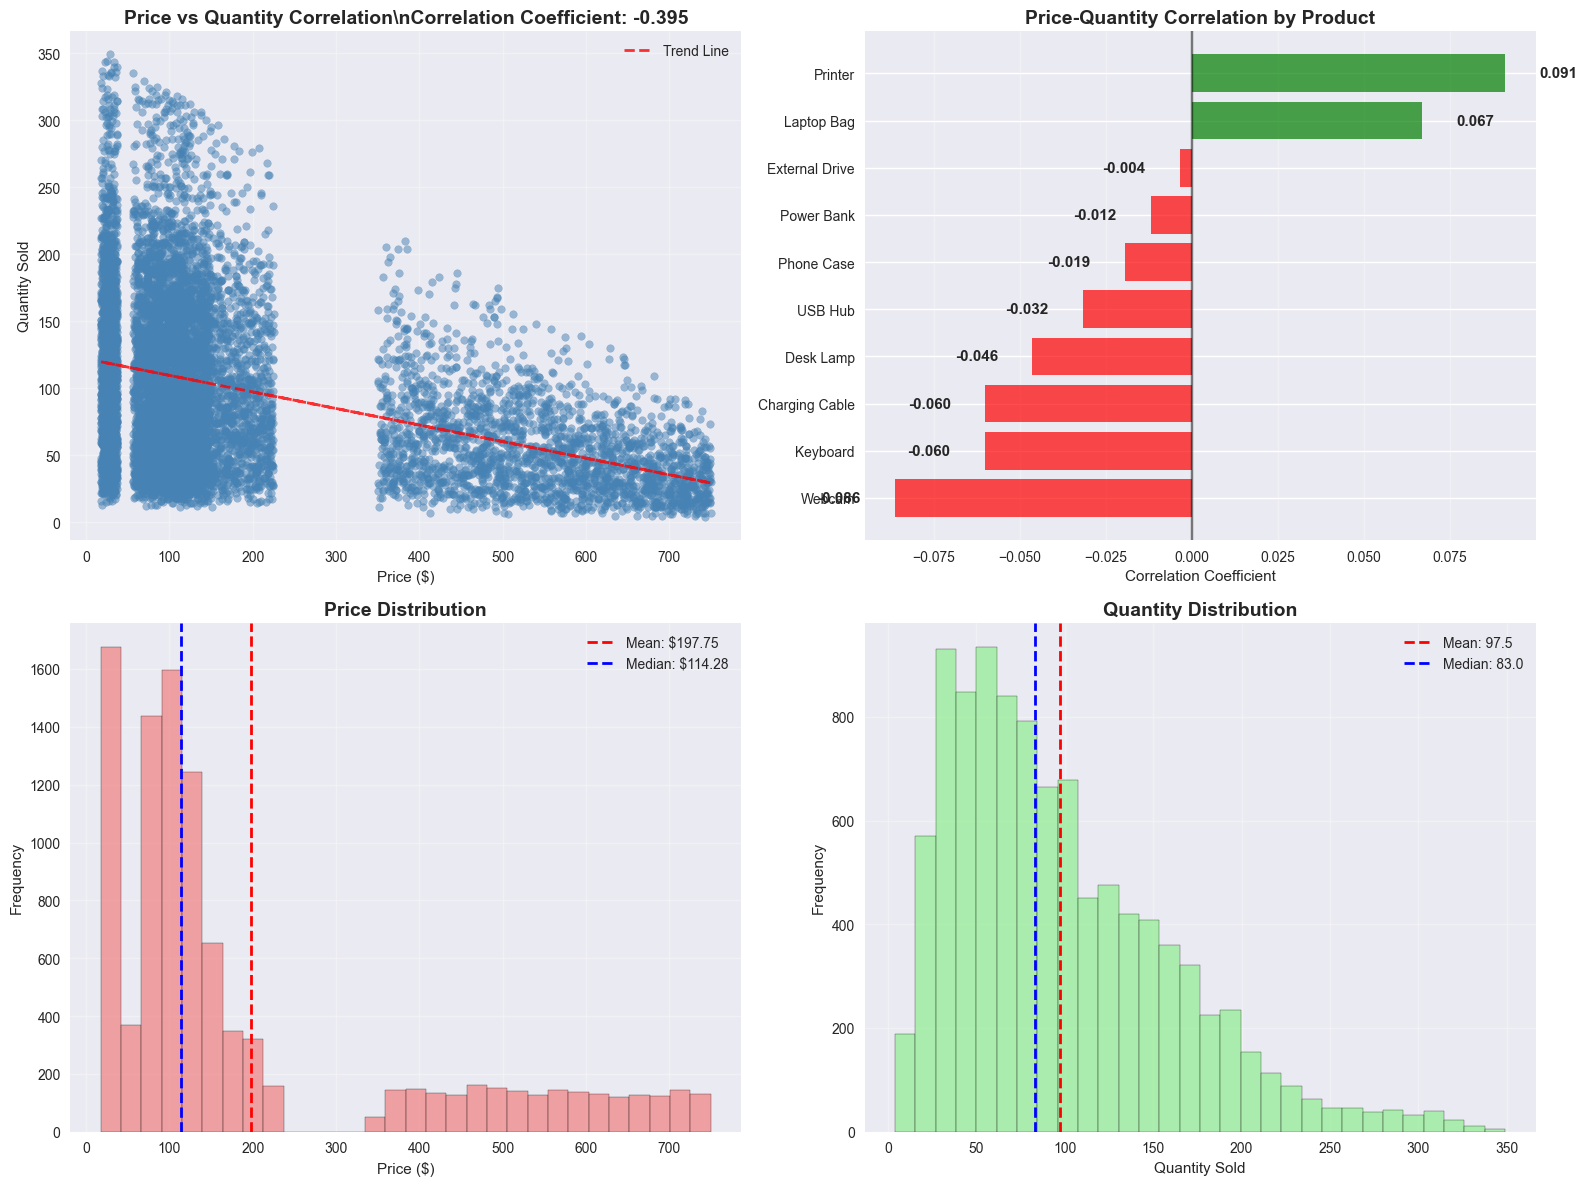

PRICE-QUANTITY CORRELATION ANALYSIS:
Overall Correlation Coefficient: -0.3947
Correlation Strength: Moderate Negative
Interpretation: Higher prices tend to be associated with lower quantities (price sensitivity)
\nPrice Statistics:
  Average Price: $197.75
  Price Range: $17.50 - $749.88
\nQuantity Statistics:
  Average Quantity: 97.5
  Quantity Range: 4 - 349


In [19]:
# 5.2 - Price vs Quantity Correlation Analysis
correlation_coefficient = sales_df['Price'].corr(sales_df['Quantity'])

# Create detailed correlation analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scatter plot of Price vs Quantity
scatter = ax1.scatter(sales_df['Price'], sales_df['Quantity'], 
                     alpha=0.5, s=30, c='steelblue')
ax1.set_title(f'Price vs Quantity Correlation\\nCorrelation Coefficient: {correlation_coefficient:.3f}', 
             fontweight='bold', fontsize=14)
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Quantity Sold')
ax1.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(sales_df['Price'], sales_df['Quantity'], 1)
p = np.poly1d(z)
ax1.plot(sales_df['Price'], p(sales_df['Price']), "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax1.legend()

# Plot 2: Correlation by Product Category (top 10 products)
top_products = sales_df.groupby('Product')['Quantity'].sum().nlargest(10).index
product_correlations = []

for product in top_products:
    product_data = sales_df[sales_df['Product'] == product]
    if len(product_data) > 1:  # Need at least 2 points for correlation
        corr = product_data['Price'].corr(product_data['Quantity'])
        product_correlations.append((product, corr if not pd.isna(corr) else 0))

product_correlations.sort(key=lambda x: x[1])
products, correlations = zip(*product_correlations)

colors = ['red' if corr < 0 else 'green' for corr in correlations]
bars = ax2.barh(products, correlations, color=colors, alpha=0.7)
ax2.set_title('Price-Quantity Correlation by Product', fontweight='bold', fontsize=14)
ax2.set_xlabel('Correlation Coefficient')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# Add correlation values on bars
for bar, corr in zip(bars, correlations):
    width = bar.get_width()
    ax2.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{corr:.3f}', ha='left' if width >= 0 else 'right', va='center', fontweight='bold')

# Plot 3: Price Distribution
ax3.hist(sales_df['Price'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
ax3.axvline(sales_df['Price'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: ${sales_df["Price"].mean():.2f}')
ax3.axvline(sales_df['Price'].median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Median: ${sales_df["Price"].median():.2f}')
ax3.set_title('Price Distribution', fontweight='bold', fontsize=14)
ax3.set_xlabel('Price ($)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Quantity Distribution
ax4.hist(sales_df['Quantity'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
ax4.axvline(sales_df['Quantity'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {sales_df["Quantity"].mean():.1f}')
ax4.axvline(sales_df['Quantity'].median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Median: {sales_df["Quantity"].median():.1f}')
ax4.set_title('Quantity Distribution', fontweight='bold', fontsize=14)
ax4.set_xlabel('Quantity Sold')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation insights
print("PRICE-QUANTITY CORRELATION ANALYSIS:")
print("="*50)
print(f"Overall Correlation Coefficient: {correlation_coefficient:.4f}")

if correlation_coefficient > 0.5:
    strength = "Strong Positive"
elif correlation_coefficient > 0.3:
    strength = "Moderate Positive"
elif correlation_coefficient > -0.3:
    strength = "Weak"
elif correlation_coefficient > -0.5:
    strength = "Moderate Negative"
else:
    strength = "Strong Negative"

print(f"Correlation Strength: {strength}")
print(f"Interpretation: ", end="")

if correlation_coefficient > 0.3:
    print("Higher prices tend to be associated with higher quantities (premium products)")
elif correlation_coefficient < -0.3:
    print("Higher prices tend to be associated with lower quantities (price sensitivity)")
else:
    print("No strong linear relationship between price and quantity")

print(f"\\nPrice Statistics:")
print(f"  Average Price: ${sales_df['Price'].mean():.2f}")
print(f"  Price Range: ${sales_df['Price'].min():.2f} - ${sales_df['Price'].max():.2f}")
print(f"\\nQuantity Statistics:")
print(f"  Average Quantity: {sales_df['Quantity'].mean():.1f}")
print(f"  Quantity Range: {sales_df['Quantity'].min()} - {sales_df['Quantity'].max()}")